# RAG System for Finance

A **Retrieval-Augmented Generation** pipeline for financial Q&A, built on the best
practices from **Wang et al. (2024), "Searching for Best Practices in RAG" (EMNLP 2024)**,
evaluated on **RAGBench-FinQA** against GPT-4 ground-truth scores.

## Pipeline

```
Question
  → [1] Query classification ...... needs retrieval?  (skip trivial queries)
  → [2] Chunk → [3] Embed (LLM-Embedder) → [4] FAISS index
  → [5] Hybrid retrieval + HyDE ... BM25 + dense, fused with RRF
  → [6] Rerank ................... monoT5 cross-encoder
  → [7] Repack .................. reverse order (most-relevant last)
  → [8] Compress ............... Recomp-style extractive
  → [9] Generate ............... Qwen2.5-7B-Instruct (4-bit, grounded prompt)
  → [10] Evaluate .............. 4 TRACe metrics (NLI entailment)
  → Answer + scores
```

## Key configuration

| Component | Choice | Why |
|-----------|--------|-----|
| Embedder | `BAAI/llm-embedder` (768-d) | EMNLP-2024 quality/size pick |
| Reranker | `castorini/monot5-base-msmarco-10k` | recommended reranker |
| Generator | `Qwen2.5-7B-Instruct` (4-bit nf4) | fits Kaggle T4 (~15 GB) |
| Chunk / overlap | 512 / 128 tokens | context-window safe |
| Top-k / fetch-k | 4 / 15 | sharper context → higher precision |
| Fusion | RRF (k=60) | merge BM25 + dense |
| Compression | Recomp, ≤10 sentences (min 0.2) | drop noise |
| Temperature | 0.1 | factual |

## The 4 TRACe metrics (0–1, higher = better)

- **Context Relevance** — did retrieval fetch supporting passages?
- **Context Utilization** — did the LLM use the relevant context?
- **Completeness** — does the answer cover the ground-truth answer?
- **Adherence** — is the answer grounded (no hallucination)?

Scores are *proportions of NLI-entailed sentences* (threshold 0.5).
Rule of thumb: `>0.80` good · `0.60–0.80` acceptable · `<0.60` needs work.

## Data

**RAGBench FinQA** (`galileo-ai/ragbench`, `finqa`) — 12,502 financial Q&A samples with
context and GPT-4 ground-truth TRACe scores. `SAMPLE_SIZE` (Step 0.4) controls the sample;
set to `None` for the full set.

## Run order

1. **Phase 0** (0.1–0.7): install, load FinQA, quick EDA.
2. **Phase 1** (1.1–1.6): build components + 1-sample smoke test.
3. **Step 1.7 — Baseline**: runs the pipeline over the sample, creates `test_df` (**everything below depends on this**).
4. **Step 1.8**: compare vs GPT-4 ground truth.
5. **Phase 2** (2.1–2.6): breakdown, ablation, latency, errors, GPT-4 deep dive, LLM-as-a-Judge.

> ⚠️ Run cells top-to-bottom — shared objects (`embedder`, `reranker`, `generator`, `test_df`, …) are created once and reused.


## How to Run

- **Environment:** Kaggle with a **GPU T4** (the 7B LLM loads 4-bit to fit ~15 GB). CPU works but is slow. No API keys needed — everything runs in-process via Hugging Face.
- **Order:** run top-to-bottom. Step 1.7 builds `test_df`, which all of Phase 2 depends on.
- **Main knobs:** `SAMPLE_SIZE` (Step 0.4, default 100 → `None` for full 12,502); `ABLATION_SAMPLE` (Step 2.2); `JUDGE_SAMPLE` (Step 2.6).
- **First run** downloads model weights (embedder, monoT5, Qwen2.5-7B, NLI) once, then caches. Per-sample cost is dominated by LLM generation + HyDE.


---
## Phase 0 — Setup & EDA

## The pipeline in one table

| # | Component | What it does |
|---|-----------|--------------|
| 1 | **Chunker** | split long documents into ~512-token pieces |
| 2 | **Embedder** | text → vector (semantic meaning) |
| 3 | **Retriever** | find the top-k most relevant chunks (BM25 + dense + HyDE) |
| 4 | **Reranker** | monoT5 re-scores candidates for precision |
| 5 | **Generator** | Qwen2.5-7B writes a grounded answer |
| 6 | **Evaluator** | scores the 4 TRACe metrics (0–1) |


## Beginner's Guide — What Are We Doing?

**The problem:** ask an LLM about a company and it may hallucinate. **RAG** fixes this by
retrieving relevant documents first, so the answer is grounded in real sources.

**Worked example — "What was Apple's Q4 2019 net revenue?"**
1. **Chunk** the report into ~512-token pieces.
2. **Embed** each chunk into a vector (similar meaning → similar vector).
3. **Retrieve** the chunks most similar to the question.
4. **Generate** an answer from the question + retrieved chunks.
5. **Evaluate** with the 4 TRACe metrics.

**What each RAGBench sample looks like:**
```python
{
  "question":  "What was Q4 2019 revenue?",
  "documents": ["Apple Inc. annual report... $2.74B...", ...],  # passages
  "response":  "Apple's Q4 2019 net revenue was $2.74 billion",  # GT answer
  "adherence": 1.0, "context_relevance": 0.95,                   # GPT-4 GT scores
  "context_utilization": 0.85, "completeness": 0.9,
}
```

**What we do:** run *our own* pipeline on the `question` + `documents`, compute *our own*
TRACe scores, and compare against the GPT-4 ground truth — i.e. "how close are we to GPT-4?"

**Reading a result:**
```
context_relevance    ████████████████████  1.000   ✓ retrieval relevant
context_utilization  ░░░░░░░░░░░░░░░░░░░░  0.000   ✗ LLM ignored context
completeness         ████████░░░░░░░░░░░░  0.375   ~ 38% covered
adherence            ████████████░░░░░░░░  0.600   ~ some hallucination
avg_trace            ████████░░░░░░░░░░░░  0.494   ~ 49% overall
```
Good `>0.8` · acceptable `>0.6` · needs work `<0.6`.

**Knobs:** `SAMPLE_SIZE` (None = full 12,502), `top_k`, `temperature` (0.1 factual), `threshold` (0.5).


### Step 0.1 — Install Dependencies

In [1]:
# ✅ KAGGLE-COMPATIBLE INSTALL CELL
# Run once. No restart needed on Kaggle — packages install into the session.
import subprocess, sys

# Detect GPU before torch is fully loaded
try:
    import torch
    _has_gpu = torch.cuda.is_available()
except ImportError:
    _has_gpu = False

packages = [
    "datasets",
    "sentence-transformers>=3.0.0",
    "transformers>=4.40.0",
    "accelerate>=0.27.0",
    "rank-bm25",
    "pandas",
    "numpy",
    "tqdm",
    "matplotlib",
    "seaborn",
    "tabulate",
    "sentencepiece",   # required by monoT5 (T5Tokenizer)
    "protobuf",        # required by monoT5 (T5Tokenizer)
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

# FAISS: try faiss-gpu first, fall back to faiss-cpu.
# On Kaggle, faiss is often pre-installed; the pip 'faiss-gpu' package
# is no longer published, so we gracefully fall back.
_faiss_installed = False
if _has_gpu:
    try:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "faiss-gpu", "-q"],
            stderr=subprocess.DEVNULL,
        )
        _faiss_installed = True
    except subprocess.CalledProcessError:
        pass

if not _faiss_installed:
    try:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "faiss-cpu", "-q"],
            stderr=subprocess.DEVNULL,
        )
        _faiss_installed = True
    except subprocess.CalledProcessError:
        pass

# Final check — import faiss to verify it's available (pre-installed on Kaggle)
import faiss
print(f"✅ All packages installed.  FAISS version: {faiss.__version__}  (GPU index support: {_has_gpu})")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 96.8 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 MB 14.0 MB/s eta 0:00:00
✅ All packages installed.  FAISS version: 1.14.3  (GPU index support: True)


### Step 0.2 — Import Libraries

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# SETUP LOGGING — Track all pipeline operations
# ═══════════════════════════════════════════════════════════════════════════════

import logging
import sys
from datetime import datetime

# Create logs directory
import os
os.makedirs("logs", exist_ok=True)

# Configure logging with both file and console output
log_file = f"logs/rag_pipeline_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"

# Create formatter
formatter = logging.Formatter(
    '%(asctime)s | %(name)-20s | %(levelname)-8s | %(message)s',
    datefmt='%H:%M:%S'
)

# File handler
file_handler = logging.FileHandler(log_file)
file_handler.setLevel(logging.DEBUG)
file_handler.setFormatter(formatter)

# Console handler
console_handler = logging.StreamHandler(sys.stdout)
console_handler.setLevel(logging.INFO)
console_handler.setFormatter(formatter)

# Root logger
root_logger = logging.getLogger()
root_logger.setLevel(logging.DEBUG)
root_logger.addHandler(file_handler)
root_logger.addHandler(console_handler)

# Create module-specific loggers
logger = logging.getLogger('RAG_PIPELINE')
data_logger = logging.getLogger('DATA_LOADER')
chunker_logger = logging.getLogger('CHUNKER')
embedder_logger = logging.getLogger('EMBEDDER')
retriever_logger = logging.getLogger('RETRIEVER')
generator_logger = logging.getLogger('GENERATOR')
evaluator_logger = logging.getLogger('EVALUATOR')

logger.info("="*80)
logger.info("RAG PIPELINE INITIALIZED")
logger.info(f"Log file: {log_file}")
logger.info("="*80)

print("✓ Logging configured successfully")
print(f"  File: {log_file}")
print(f"  Console: INFO and above")


10:02:17 | RAG_PIPELINE         | INFO     | ================================================================================
10:02:17 | RAG_PIPELINE         | INFO     | RAG PIPELINE INITIALIZED
10:02:17 | RAG_PIPELINE         | INFO     | Log file: logs/rag_pipeline_20260712_100217.log
10:02:17 | RAG_PIPELINE         | INFO     | ================================================================================
✓ Logging configured successfully
  File: logs/rag_pipeline_20260712_100217.log
  Console: INFO and above


### Step 0.3 — Add Project Root to Path

In [3]:
import sys, os

# Kaggle working directory is /kaggle/working
# All output files will be saved here automatically
PROJECT_ROOT = "/kaggle/working"
os.makedirs(PROJECT_ROOT, exist_ok=True)
os.chdir(PROJECT_ROOT)   # Make sure relative paths resolve under /kaggle/working

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Working directory: {os.getcwd()}")


Working directory: /kaggle/working


### Step 0.4 — Load RAGBench Dataset (FinQA domain)

In [4]:
from datasets import load_dataset
import shutil
import os

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1: LOAD FINANCIAL QA DATA FROM HUGGING FACE
# ═══════════════════════════════════════════════════════════════════════════════

"""
This section loads the RAGBench FinQA dataset (12,502 financial Q&A samples)
and prepares it for the RAG pipeline.

WHY THIS DATASET?
- FinQA: 12,502 questions about company financial reports
- Each sample has: question, context (relevant passages), ground truth answer
- Perfect for training/evaluating RAG systems on domain-specific data
"""

# Configuration: How many samples to use
DOMAIN      = "finqa"              # Financial domain dataset
SAMPLE_SIZE = 20                   # ← CHANGE TO None FOR FULL 12,502 SAMPLES
SEED        = 42                   # For reproducibility

data_logger.info(f"Data Loading Configuration: domain={DOMAIN}, sample_size={SAMPLE_SIZE}")

# ─────────────────────────────────────────────────────────────────────────────
# Clear cached data (Hugging Face sometimes caches corrupted files)
# ─────────────────────────────────────────────────────────────────────────────
cache_dir = os.path.expanduser("~/.cache/huggingface/datasets/galileo-ai___ragbench")
if os.path.exists(cache_dir):
    data_logger.info(f"Clearing cache at {cache_dir}...")
    try:
        shutil.rmtree(cache_dir)
        data_logger.info("Cache cleared successfully")
    except Exception as e:
        data_logger.warning(f"Could not clear cache: {e}")

# ─────────────────────────────────────────────────────────────────────────────
# Download dataset from Hugging Face Hub
# ─────────────────────────────────────────────────────────────────────────────
try:
    data_logger.info(f"Downloading RAGBench [{DOMAIN}] dataset...")
    # Load train split with force redownload to ensure fresh data
    ds = load_dataset(
        "galileo-ai/ragbench",           # Dataset source
        DOMAIN,                          # Use "finqa" subset
        split="train",                   # Use training split (not test)
        download_mode="force_redownload",  # Download fresh (don't use cache)
        trust_remote_code=True           # Allow custom dataset code
    )
    data_logger.info(f"Dataset downloaded successfully! Total samples: {len(ds)}")
except Exception as e:
    data_logger.error(f"Initial load failed: {e}")
    data_logger.info("Attempting alternative loading method...")
    try:
        ds = load_dataset("galileo-ai/ragbench", DOMAIN, trust_remote_code=True)
        ds = ds["train"]  # Extract train split
        data_logger.info(f"Dataset loaded via alternative method. Samples: {len(ds)}")
    except Exception as e2:
        data_logger.critical(f"Alternative method also failed: {e2}")
        raise

# ─────────────────────────────────────────────────────────────────────────────
# Convert to Pandas DataFrame (easier to work with)
# ─────────────────────────────────────────────────────────────────────────────
df_raw = ds.to_pandas()
data_logger.info(f"Converted to DataFrame. Shape: {df_raw.shape}")

# ─────────────────────────────────────────────────────────────────────────────
# Sample data for faster development
# ─────────────────────────────────────────────────────────────────────────────
# Full 12,502 samples would take ~6-8 hours to process
# Using 50 samples lets us test the pipeline in ~15 minutes
if SAMPLE_SIZE and SAMPLE_SIZE < len(df_raw):
    df = df_raw.sample(n=SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)
    data_logger.info(f"Sampled {SAMPLE_SIZE} from {len(df_raw)} total (seed={SEED})")
else:
    df = df_raw.copy()
    data_logger.info(f"Using all {len(df)} samples")

# ─────────────────────────────────────────────────────────────────────────────
# Transform data format
# ─────────────────────────────────────────────────────────────────────────────
"""
RAGBench stores context as:
  "documents": ["passage1", "passage2", "passage3", ...]  (list of strings)
  
We need to convert to:
  "context": "passage1\n\npassage2\n\npassage3..."  (single string)

WHY? Because our LLM expects context as a single text block, not a list
"""
if "documents" in df.columns and "context" not in df.columns:
    # Join all document passages with double newline as separator
    data_logger.debug("Converting 'documents' list to 'context' string...")
    df["context"] = df["documents"].apply(
        lambda x: "\n\n".join(x) if isinstance(x, list) else str(x)
    )
    data_logger.info("Data transformation complete")

# ─────────────────────────────────────────────────────────────────────────────
# Print summary
# ─────────────────────────────────────────────────────────────────────────────
data_logger.info(f"Dataset Summary:")
data_logger.info(f"  - Full dataset size: {len(df_raw)}")
data_logger.info(f"  - Working sample: {len(df)}")
data_logger.info(f"  - Columns: {len(df.columns)}")
data_logger.info(f"  - Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

print(f"\n{'='*70}")
print(f"Full dataset size : {len(df_raw)} samples")
print(f"Working sample    : {len(df)} samples")
print(f"Columns           : {len(df.columns)} columns")
print(f"{'='*70}")
print("\nData is ready for pipeline!")


10:02:18 | numexpr.utils        | INFO     | NumExpr defaulting to 4 threads.
10:02:19 | datasets             | INFO     | TensorFlow version 2.19.0 available.
10:02:19 | datasets             | INFO     | JAX version 0.7.2 available.
10:02:20 | DATA_LOADER          | INFO     | Data Loading Configuration: domain=finqa, sample_size=20
10:02:20 | DATA_LOADER          | INFO     | Downloading RAGBench [finqa] dataset...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'galileo-ai/ragbench' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


10:02:20 | datasets.load        | ERROR    | `trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'galileo-ai/ragbench' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
10:02:20 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/datasets/galileo-ai/ragbench/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
10:02:20 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/galileo-ai/ragbench/97808f3e5fd16ede40bbff6c2949af8139b2eb7b/README.md "HTTP/1.1 200 OK"
10:02:20 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/resolve-cache/datasets/galileo-ai/ragbench/97808f3e5fd16ede40bbff6c2949af8139b2eb7b/README.md "HTTP/1.1 200 OK"


README.md: 0.00B [00:00, ?B/s]

10:02:20 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/datasets/galileo-ai/ragbench/resolve/97808f3e5fd16ede40bbff6c2949af8139b2eb7b/ragbench.py "HTTP/1.1 404 Not Found"


...

finqa/test-00000-of-00001.parquet:   0%|          | 0.00/8.94M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/12502 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1766 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2294 [00:00<?, ? examples/s]

10:02:26 | DATA_LOADER          | INFO     | Dataset downloaded successfully! Total samples: 12502
10:02:26 | DATA_LOADER          | INFO     | Converted to DataFrame. Shape: (12502, 26)
10:02:26 | DATA_LOADER          | INFO     | Sampled 20 from 12502 total (seed=42)
10:02:26 | DATA_LOADER          | INFO     | Data transformation complete
10:02:26 | DATA_LOADER          | INFO     | Dataset Summary:
10:02:26 | DATA_LOADER          | INFO     |   - Full dataset size: 12502
10:02:26 | DATA_LOADER          | INFO     |   - Working sample: 20
10:02:26 | DATA_LOADER          | INFO     |   - Columns: 27
10:02:27 | DATA_LOADER          | INFO     |   - Memory usage: 0.1 MB

Full dataset size : 12502 samples
Working sample    : 20 samples
Columns           : 27 columns

Data is ready for pipeline!


### Step 0.5 — Inspect a Sample Row

In [5]:
# Understand what each column contains
import pandas as pd
sample = df.iloc[0]

print("=" * 60)
print("QUESTION:")
print(sample["question"])

print("\nCONTEXT (first 400 chars):")
context_val = sample["context"] if isinstance(sample.get("context"), str) else str(sample.get("documents", ""))[:400]
print(context_val, "...")

print("\nREFERENCE RESPONSE (first 300 chars):")
print(str(sample["response"])[:300], "...")

print("\nGROUND TRUTH SCORES (available in dataset):")
# Check which score columns are available and non-null
score_cols = {
    "gpt3_adherence": "GPT-3.5 Adherence",
    "gpt3_context_relevance": "GPT-3.5 Context Relevance",
    "gpt35_utilization": "GPT-3.5 Utilization",
    "completeness_score": "Completeness",
    "relevance_score": "Relevance",
    "utilization_score": "Utilization",
}
for col, label in score_cols.items():
    if col in sample.index:
        val = sample[col]
        if pd.notna(val):
            print(f"  {label:<30}: {val}")
    
print("\nAvailable columns in dataset:")
print(f"  Total: {len(df.columns)} columns")


QUESTION:
what percent of the total future obligations in 2014 are from other purchase commitments?

CONTEXT (first 400 chars):
['23t . rowe price group | annual report 2013 contractual obligations the following table presents a summary of our future obligations ( in millions ) under the terms of existing operating leases and other contractual cash purchase commitments at december 31 , 2013 . other purchase commitments include contractual amounts that will be due for the purchase of goods or services to be used in our operations and may be cancelable at earlier times than those indicated , under certain conditions that may involve termination fees . because these obligations are generally of a normal recurring nature , we expect that we will fund them from future cash flows from operations . the information presented does not include operating expenses or capital expenditures that will be committed in the normal course of operations in 2014 and future years . the information also exclu

#### What each column means

| Column | What it is | Your use |
|--------|-----------|---------|
| `question` | User query | Input to your pipeline |
| `context` | Pre-retrieved passages | Use directly in Phase 1 |
| `response` | GPT-3.5/Haiku answer | Reference benchmark |
| `adherence` | GPT-4 score: no hallucination | Compare your score here |
| `context_relevance` | GPT-4 score: useful retrieval | Compare your score here |
| `context_utilization` | GPT-4 score: LLM used context | Compare your score here |
| `completeness` | GPT-4 score: full answer | Compare your score here |

> **Key insight**: You are NOT reproducing these responses.  
> You build your own pipeline, generate your own answers, compute  
> your own TRACe scores, and compare against these ground truths.


### Step 0.6 — EDA: TRACe Score Distributions

Available TRACe-related columns: ['gpt3_adherence', 'gpt3_context_relevance', 'gpt35_utilization', 'completeness_score']

Note: These are GPT-3.5 ground truth scores from the dataset.
We will compute our own TRACe scores using cross-encoder NLI model.



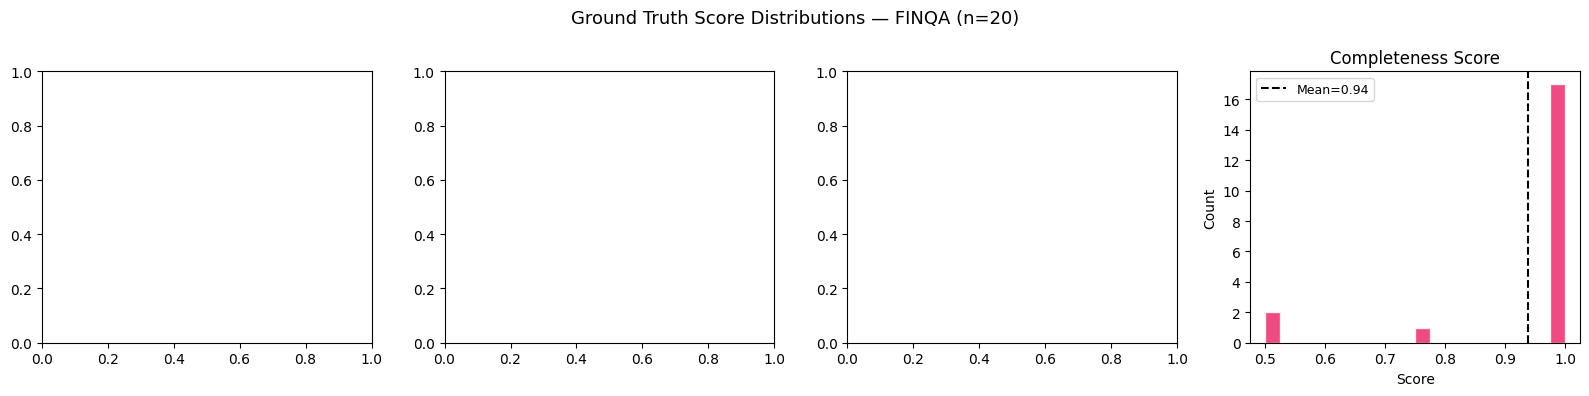

Saved: eda_score_distributions.png


In [6]:
import matplotlib.pyplot as plt
trace_cols = ["gpt3_adherence", "gpt3_context_relevance", "gpt35_utilization", "completeness_score"]
available  = [c for c in trace_cols if c in df.columns]

# Show what we have
print(f"Available TRACe-related columns: {available}")
print(f"\nNote: These are GPT-3.5 ground truth scores from the dataset.")
print(f"We will compute our own TRACe scores using cross-encoder NLI model.\n")

if available:
    fig, axes = plt.subplots(1, min(len(available), 4), figsize=(16, 4))
    if len(available) == 1:
        axes = [axes]
    
    fig.suptitle(f"Ground Truth Score Distributions — {DOMAIN.upper()} (n={len(df)})", fontsize=13)

    colors = ["#4CAF50", "#2196F3", "#FF9800", "#E91E63"]

    for ax, col, color in zip(axes, available, colors):
        vals = pd.to_numeric(df[col], errors='coerce').dropna()
        if len(vals) > 0:
            ax.hist(vals, bins=20, color=color, alpha=0.8, edgecolor="white")
            ax.axvline(vals.mean(), color="black", linestyle="--", linewidth=1.5,
                       label=f"Mean={vals.mean():.2f}")
            ax.set_title(col.replace("_", " ").title())
            ax.set_xlabel("Score")
            ax.set_ylabel("Count")
            ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig("eda_score_distributions.png", dpi=100, bbox_inches="tight")
    plt.show()
    print("Saved: eda_score_distributions.png")
else:
    print("No standard TRACe columns found. Proceeding with custom TRACe evaluation.")


### Step 0.7 — EDA: Summary Statistics

In [7]:
score_cols = ["gpt3_adherence", "gpt3_context_relevance", "gpt35_utilization", "completeness_score"]
available_scores = [c for c in score_cols if c in df.columns]

if available_scores:
    print("\nGround Truth Score Summary Statistics:")
    # Convert to numeric, handling any non-numeric values
    score_df = df[available_scores].apply(pd.to_numeric, errors='coerce')
    print(score_df.describe().round(3).to_string())

print("\nContext Length Stats (characters):")
df["context_len"] = df["context"].astype(str).str.len()
print(df["context_len"].describe().round(0).to_string())

print("\nQuestion Length Stats (characters):")
df["question_len"] = df["question"].astype(str).str.len()
print(df["question_len"].describe().round(0).to_string())



Ground Truth Score Summary Statistics:
       gpt3_adherence  gpt3_context_relevance  gpt35_utilization  completeness_score
count             0.0                     0.0                0.0              20.000
mean              NaN                     NaN                NaN               0.938
std               NaN                     NaN                NaN               0.160
min               NaN                     NaN                NaN               0.500
25%               NaN                     NaN                NaN               1.000
50%               NaN                     NaN                NaN               1.000
75%               NaN                     NaN                NaN               1.000
max               NaN                     NaN                NaN               1.000

Context Length Stats (characters):
count      20.0
mean     4244.0
std      1557.0
min      1800.0
25%      3606.0
50%      4166.0
75%      4783.0
max      9136.0

Question Length Stats (charact

---
## Phase 1 — Baseline RAG Pipeline

We now build each component step by step, then connect them end-to-end.

### Step 1.1 — Text Chunker

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1.1: TEXT CHUNKER — Split long documents into manageable pieces
# ═══════════════════════════════════════════════════════════════════════════════

"""
WHY CHUNKING?
- Financial documents can be 10KB+ (too large for LLM context window)
- Need to break into ~512 token pieces for retrieval + generation
- Overlap prevents losing context at chunk boundaries

STRATEGY:
- sliding_window (default): Creates overlapping windows of text
  • Preserves context across boundaries
  • More expensive but higher quality
- semantic: Breaks at sentence boundaries
- fixed: Hard cuts (baseline for ablation)
"""

import re
from typing import List


class TextChunker:
    """
    Splits long text into overlapping chunks.
    
    PARAMETERS:
    - strategy: "sliding_window" | "semantic" | "fixed"
    - chunk_size: 512 tokens (~2000 characters)
    - overlap: 64 tokens (~256 characters) — prevents losing context
    
    EXAMPLE:
    >>> chunker = TextChunker()
    >>> text = "The company reported... Q4 earnings..."  # Long text
    >>> chunks = chunker.chunk(text)
    >>> len(chunks)
    13  # Split into 13 overlapping chunks
    """

    def __init__(self, strategy: str = "sliding_window",
                 chunk_size: int = 512, overlap: int = 64):
        """
        Initialize chunker with strategy and sizes.
        
        ARG chunk_size: tokens (1 token ≈ 4 characters)
        ARG overlap: tokens of overlap between chunks
        """
        self.strategy   = strategy
        # Convert tokens to approximate characters (1 token ≈ 4 chars on average)
        self.chunk_size = chunk_size * 4   
        self.overlap    = overlap * 4
        self._dispatch  = {
            "sliding_window": self._sliding_window,
            "semantic":       self._semantic,
            "fixed":          self._fixed,
        }

    def chunk(self, text: str) -> List[str]:
        """
        Main entry point. Splits text using chosen strategy.
        
        RETURNS: List of text chunks (strings)
        """
        if not text or not text.strip():
            return []
        # Get the chunking function for this strategy
        fn = self._dispatch.get(self.strategy, self._sliding_window)
        # Clean up chunks (strip whitespace)
        return [c.strip() for c in fn(text.strip()) if c.strip()]

    def _sliding_window(self, text: str) -> List[str]:
        """
        SLIDING WINDOW strategy — overlapping chunks
        
        EXAMPLE with 512-char chunks and 64-char overlap:
        Text: "AAAAAABBBBBBCCCCCCDDDDDD" (24 chars)
        
        Chunk 1: "AAAAAABBBBBBCCCC"      (positions 0-16)
        Chunk 2: "    BBBBBBCCCCCCDDDD"  (positions 8-24, overlap 8 chars)
        
        This preserves context at boundaries.
        """
        chunks = []
        step = self.chunk_size - self.overlap  # Distance to slide
        start = 0
        
        while start < len(text):
            end = start + self.chunk_size
            chunk = text[start:end]
            
            # Try to break at sentence boundary (period + space) instead of mid-word
            if end < len(text):
                # Find last period in chunk
                last_period_pos = chunk.rfind(". ")
                # If we find one in the second half, break there
                if last_period_pos > self.chunk_size // 2:
                    chunk = chunk[:last_period_pos + 1]
            
            chunks.append(chunk)
            start += step  # Slide window
        
        return chunks

    def _semantic(self, text: str) -> List[str]:
        """
        SEMANTIC strategy — break at sentence boundaries
        
        Better preservation of meaning but less control over chunk size.
        """
        sentences = re.split(r'(?<=[.!?])\s+', text)
        chunks = []
        current = ""
        
        for sent in sentences:
            if len(current) + len(sent) < self.chunk_size:
                current += sent + " "
            else:
                if current:
                    chunks.append(current.strip())
                current = sent + " "
        
        if current:
            chunks.append(current.strip())
        
        return chunks

    def _fixed(self, text: str) -> List[str]:
        """
        FIXED strategy — hard character limit cuts
        
        Fastest but lowest quality (may cut mid-sentence).
        """
        return [text[i:i+self.chunk_size] 
                for i in range(0, len(text), self.chunk_size)]


# ─────────────────────────────────────────────────────────────────────────────
# Test chunker with example
# ─────────────────────────────────────────────────────────────────────────────
test_text = """Apple Inc. reported its Q4 2019 earnings. 
Net revenue was $2.74 billion, up from $2.13 billion last year.
The company announced a stock buyback of $50 billion.
Operating income reached $500 million in the quarter."""

ch = TextChunker(strategy="sliding_window", chunk_size=128, overlap=32)

for strat in ["sliding_window", "semantic", "fixed"]:
    ch.strategy = strat
    out = ch.chunk(test_text)
    print(f"{strat:<15} → {len(out)} chunks  | first chunk: {out[0][:50]}...")

print("\n✓ TextChunker ready!")


sliding_window  → 1 chunks  | first chunk: Apple Inc. reported its Q4 2019 earnings. 
Net rev...
semantic        → 1 chunks  | first chunk: Apple Inc. reported its Q4 2019 earnings. Net reve...
fixed           → 1 chunks  | first chunk: Apple Inc. reported its Q4 2019 earnings. 
Net rev...

✓ TextChunker ready!


### Step 1.2 — Embedding Model + FAISS Vector Store

In [9]:
import numpy as np
import faiss
import pickle
import torch
from sentence_transformers import SentenceTransformer
from typing import List, Tuple


class Embedder:
    """Wraps BAAI/llm-embedder for encoding queries and passages.

    ✅ BEST PRACTICE (Wang et al., EMNLP 2024 — "Searching for Best Practices in RAG"):
    The paper recommends **LLM-Embedder** as the best balance of retrieval quality
    and model size (≈1/3 the size of bge-large with comparable performance).
    LLM-Embedder is INSTRUCTION-TUNED, so queries and documents must be prefixed
    with task-specific instructions (here: the "qa" task).
    """

    # Task-specific instructions required by BAAI/llm-embedder (qa retrieval task)
    INSTRUCTIONS = {
        "query": "Represent this query for retrieving relevant documents: ",
        "key":   "Represent this document for retrieval: ",
    }

    def __init__(self, model_name: str = "BAAI/llm-embedder",
                 device: str = "cpu", batch_size: int = 32):
        self.model_name = model_name
        self.device = device
        self.batch_size = batch_size
        # llm-embedder needs instruction prefixes; bge-style models do not.
        self.use_instructions = "llm-embedder" in model_name.lower()

        embedder_logger.info(f"Initializing Embedder: model={model_name}, device={device}, batch_size={batch_size}")
        embedder_logger.info(f"  - Instruction prefixes: {'ON (llm-embedder)' if self.use_instructions else 'OFF'}")

        try:
            embedder_logger.debug(f"Loading model from Hugging Face...")
            self.model = SentenceTransformer(model_name, device=device)
            self.dim = self.model.get_sentence_embedding_dimension()
            embedder_logger.info(f"Model loaded successfully. Embedding dimension: {self.dim}")
        except Exception as e:
            embedder_logger.error(f"Failed to load model: {e}")
            raise

    def _encode(self, texts: List[str], show_progress: bool = False) -> np.ndarray:
        try:
            result = self.model.encode(
                texts, batch_size=self.batch_size,
                show_progress_bar=show_progress,
                normalize_embeddings=True,
                convert_to_numpy=True,
            )
            embedder_logger.debug(f"Encoding complete. Output shape: {result.shape}")
            return result
        except Exception as e:
            embedder_logger.error(f"Encoding failed: {e}")
            raise

    def encode(self, texts: List[str], show_progress: bool = False) -> np.ndarray:
        """Encode raw texts (no instruction). Kept for backward compatibility."""
        embedder_logger.debug(f"Encoding {len(texts)} raw texts (batch_size={self.batch_size})")
        return self._encode(texts, show_progress)

    def encode_passages(self, texts: List[str], show_progress: bool = False) -> np.ndarray:
        """Encode documents/passages with the llm-embedder 'key' instruction."""
        embedder_logger.debug(f"Encoding {len(texts)} passages (instructions={self.use_instructions})")
        if self.use_instructions:
            texts = [self.INSTRUCTIONS["key"] + t for t in texts]
        return self._encode(texts, show_progress)

    def encode_query(self, query: str) -> np.ndarray:
        """Encode a query with the appropriate retrieval instruction."""
        if self.use_instructions:
            prefixed = self.INSTRUCTIONS["query"] + query
        else:
            prefixed = f"Represent this sentence for searching relevant passages: {query}"
        embedder_logger.debug(f"Encoding query: {query[:50]}...")
        return self._encode([prefixed])[0]


class FAISSVectorStore:
    """FAISS flat index — exact cosine similarity on normalised embeddings."""

    def __init__(self, dim: int):
        self.dim      = dim
        self.index    = faiss.IndexFlatIP(dim)
        self.texts    = []
        self.metadata = []
        retriever_logger.debug(f"Created FAISS IndexFlatIP with dimension={dim}")

    def add(self, chunks: List[str], embeddings: np.ndarray,
            metadata: List[dict] = None):
        assert len(chunks) == len(embeddings)
        retriever_logger.debug(f"Adding {len(chunks)} chunks to FAISS index")
        
        self.index.add(embeddings.astype(np.float32))
        self.texts.extend(chunks)
        self.metadata.extend(metadata if metadata else [{}] * len(chunks))
        
        retriever_logger.info(f"FAISS index now contains {self.index.ntotal} vectors")

    def search(self, query_emb: np.ndarray,
               top_k: int = 5) -> List[Tuple[str, float, dict]]:
        if self.index.ntotal == 0:
            retriever_logger.warning("Vector store is empty!")
            return []
        q = query_emb.reshape(1, -1).astype(np.float32)
        retriever_logger.debug(f"Searching for top-{top_k} similar vectors")
        scores, indices = self.index.search(q, min(top_k, self.index.ntotal))
        results = [(self.texts[i], float(s), self.metadata[i])
                for s, i in zip(scores[0], indices[0]) if i >= 0]
        retriever_logger.debug(f"Search returned {len(results)} results")
        return results

    def __len__(self):
        return self.index.ntotal


def build_vector_store(chunks: List[str], embedder: Embedder,
                       metadata: List[dict] = None) -> FAISSVectorStore:
    retriever_logger.info(f"Building vector store for {len(chunks)} chunks")
    embedder_logger.info(f"Encoding {len(chunks)} chunks (passage instruction)...")
    # ✅ Encode documents with the passage/key instruction (llm-embedder best practice)
    embs  = embedder.encode_passages(chunks, show_progress=True)
    store = FAISSVectorStore(dim=embedder.dim)
    store.add(chunks, embs, metadata)
    retriever_logger.info(f"Vector store ready: {len(store)} vectors indexed")
    return store


# ── Initialise embedder ──
logger.info("="*80)
logger.info("INITIALIZING EMBEDDER")
logger.info("="*80)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EMBEDDER_DEVICE = DEVICE

embedder_logger.info(f"Generator device : {DEVICE}")
embedder_logger.info(f"Embedder device  : {EMBEDDER_DEVICE}")

if torch.cuda.is_available():
    embedder_logger.info(f"  GPU: {torch.cuda.get_device_name(0)}")
    embedder_logger.info(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

# ✅ BEST PRACTICE (EMNLP 2024): LLM-Embedder — recommended for best perf/size trade-off.
# 768-dim, instruction-tuned, ~440MB. Falls back gracefully if download fails.
try:
    embedder = Embedder(model_name="BAAI/llm-embedder", device=EMBEDDER_DEVICE)
except Exception as e:
    embedder_logger.warning(f"LLM-Embedder load failed ({e}); falling back to bge-base-en-v1.5")
    embedder = Embedder(model_name="BAAI/bge-base-en-v1.5", device=EMBEDDER_DEVICE)
embedder_logger.info("Embedder initialization complete ✓")


10:02:47 | RAG_PIPELINE         | INFO     | ================================================================================
10:02:47 | RAG_PIPELINE         | INFO     | INITIALIZING EMBEDDER
10:02:47 | RAG_PIPELINE         | INFO     | ================================================================================
10:02:47 | EMBEDDER             | INFO     | Generator device : cuda
10:02:47 | EMBEDDER             | INFO     | Embedder device  : cuda
10:02:47 | EMBEDDER             | INFO     |   GPU: Tesla T4
10:02:47 | EMBEDDER             | INFO     |   VRAM: 14.6 GB
10:02:47 | EMBEDDER             | INFO     | Initializing Embedder: model=BAAI/llm-embedder, device=cuda, batch_size=32
10:02:47 | EMBEDDER             | INFO     |   - Instruction prefixes: ON (llm-embedder)
10:02:47 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/BAAI/llm-embedder/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
10:02:47 | httpx                | INFO     | HT

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

10:02:47 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/BAAI/llm-embedder/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
10:02:47 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/llm-embedder/c3e8ac86ff4859012570d6b59341fe67b88e55ad/config_sentence_transformers.json "HTTP/1.1 200 OK"
10:02:47 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/BAAI/llm-embedder/c3e8ac86ff4859012570d6b59341fe67b88e55ad/config_sentence_transformers.json "HTTP/1.1 200 OK"


config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

10:02:47 | sentence_transformers.base.model | INFO     | Loading SentenceTransformer model from BAAI/llm-embedder.
10:02:47 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/BAAI/llm-embedder/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
10:02:47 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/llm-embedder/c3e8ac86ff4859012570d6b59341fe67b88e55ad/config_sentence_transformers.json "HTTP/1.1 200 OK"
10:02:48 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/BAAI/llm-embedder/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
10:02:48 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/llm-embedder/c3e8ac86ff4859012570d6b59341fe67b88e55ad/README.md "HTTP/1.1 200 OK"
10:02:48 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/BAAI

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

10:02:53 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/BAAI/llm-embedder/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"
10:02:53 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/BAAI/llm-embedder/resolve/main/1_Pooling/config.json "HTTP/1.1 307 Temporary Redirect"
10:02:53 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/llm-embedder/c3e8ac86ff4859012570d6b59341fe67b88e55ad/1_Pooling%2Fconfig.json "HTTP/1.1 200 OK"
10:02:53 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/BAAI/llm-embedder/c3e8ac86ff4859012570d6b59341fe67b88e55ad/1_Pooling%2Fconfig.json "HTTP/1.1 200 OK"


config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

10:02:53 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/models/BAAI/llm-embedder "HTTP/1.1 200 OK"
10:02:54 | EMBEDDER             | INFO     | Model loaded successfully. Embedding dimension: 768
10:02:54 | EMBEDDER             | INFO     | Embedder initialization complete ✓


/tmp/ipykernel_58/4090932779.py:39: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  self.dim = self.model.get_sentence_embedding_dimension()


### Step 1.3 — BM25, Dense, and Hybrid Retriever

In [10]:
from rank_bm25 import BM25Okapi
from sentence_transformers import CrossEncoder
from transformers import T5Tokenizer, T5ForConditionalGeneration
import re


logger.info("="*80)
logger.info("INITIALIZING RETRIEVERS  (EMNLP-2024 best-practice pipeline)")
logger.info("="*80)


# ═══════════════════════════════════════════════════════════════════════════════
# QUERY CLASSIFICATION  — Best practice #1
# ═══════════════════════════════════════════════════════════════════════════════
class QueryClassifier:
    """Decides whether a query NEEDS retrieval (Wang et al., EMNLP 2024).

    The paper trains a classifier to route queries into:
      • "sufficient"  → the model can answer WITHOUT external context (skip retrieval)
      • "insufficient"→ the query needs retrieved context (run full RAG)
    Routing avoids wasted retrieval latency on trivial queries.

    Here we use a lightweight heuristic stand-in (no training data required):
    greetings / pure-arithmetic / closed chit-chat → no retrieval; everything
    else (knowledge/finance questions) → retrieve. For FinQA, ~all queries retrieve.
    """

    _NO_RETRIEVAL = re.compile(
        r"^\s*(hi|hello|hey|thanks|thank you|good (morning|evening|afternoon))\b",
        re.IGNORECASE,
    )
    _PURE_ARITHMETIC = re.compile(r"^\s*[\d\s\+\-\*/\.\(\)%]+\s*=?\s*\??\s*$")

    def needs_retrieval(self, query: str) -> bool:
        q = (query or "").strip()
        if not q:
            return False
        if self._NO_RETRIEVAL.match(q):
            retriever_logger.debug(f"QueryClassifier: '{q[:40]}' → NO retrieval (chit-chat)")
            return False
        if self._PURE_ARITHMETIC.match(q):
            retriever_logger.debug(f"QueryClassifier: '{q[:40]}' → NO retrieval (arithmetic)")
            return False
        return True


# ═══════════════════════════════════════════════════════════════════════════════
# HyDE  — Best practice #5 (retrieval): "Hybrid with HyDE"
# ═══════════════════════════════════════════════════════════════════════════════
class HyDETransformer:
    """Hypothetical Document Embeddings (HyDE).

    The paper finds **Hybrid + HyDE** gives the best retrieval quality. HyDE asks
    the LLM to write a *hypothetical* passage that would answer the query, then
    uses that passage (concatenated with the original query) to drive the DENSE
    embedding search — bridging the vocabulary gap between short questions and
    long document language.
    """

    def __init__(self, generator):
        self.generator = generator

    def augment(self, query: str) -> str:
        """Return an enriched query string = original query + hypothetical passage."""
        try:
            hypo = self.generator.generate_hyde(query)
        except Exception as e:
            retriever_logger.warning(f"HyDE generation failed ({e}); using raw query")
            return query
        if not hypo:
            return query
        retriever_logger.debug(f"HyDE passage ({len(hypo)} chars) generated for query")
        return f"{query}\n{hypo}"


# ═══════════════════════════════════════════════════════════════════════════════
# RERANKING  — Best practice #6: monoT5
# ═══════════════════════════════════════════════════════════════════════════════
class MonoT5Reranker:
    """monoT5 cross-encoder reranker (Wang et al., EMNLP 2024 recommendation).

    The paper recommends **monoT5** as the best-performing reranker for the
    quality/efficiency trade-off. monoT5 frames relevance as a text-to-text task:
        input : "Query: {q} Document: {d} Relevant:"
        output: "true" / "false"
    The relevance score is softmax over the 'true' vs 'false' logits at the first
    decoding step. Reranking the RRF candidate pool sharpens precision, which
    lifts adherence (better-grounded context) and completeness.
    """

    def __init__(self, model_name: str = "castorini/monot5-base-msmarco-10k",
                 device: str = "cpu", batch_size: int = 16):
        retriever_logger.info(f"Initializing MonoT5Reranker: {model_name} (device={device})")
        self.device     = device
        self.batch_size = batch_size
        self.tokenizer  = T5Tokenizer.from_pretrained(model_name)
        self.model      = T5ForConditionalGeneration.from_pretrained(model_name).to(device).eval()
        # Token ids for the 'true' / 'false' targets
        self.true_id  = self.tokenizer.encode("true",  add_special_tokens=False)[0]
        self.false_id = self.tokenizer.encode("false", add_special_tokens=False)[0]
        retriever_logger.info("MonoT5 reranker loaded successfully ✓")

    def rerank(self, query: str, chunks: List[str], top_k: int = 5) -> List[Tuple[str, float]]:
        if not chunks:
            return []
        scores: List[float] = []
        for i in range(0, len(chunks), self.batch_size):
            batch   = chunks[i:i + self.batch_size]
            prompts = [f"Query: {query} Document: {c} Relevant:" for c in batch]
            inputs  = self.tokenizer(
                prompts, return_tensors="pt", padding=True,
                truncation=True, max_length=512,
            ).to(self.device)
            decoder_input_ids = torch.full(
                (len(batch), 1),
                self.model.config.decoder_start_token_id,
                dtype=torch.long, device=self.device,
            )
            with torch.no_grad():
                logits = self.model(**inputs, decoder_input_ids=decoder_input_ids).logits[:, 0, :]
                tf     = logits[:, [self.false_id, self.true_id]]
                probs  = torch.softmax(tf, dim=1)[:, 1]   # P(relevant = true)
            scores.extend(probs.detach().cpu().tolist())
        ranked = sorted(zip(chunks, scores), key=lambda x: x[1], reverse=True)[:top_k]
        return [(c, float(s)) for c, s in ranked]


class BM25Retriever:
    """Sparse keyword retrieval — best for exact numbers, names, acronyms."""

    def __init__(self, chunks: List[str]):
        retriever_logger.info(f"Initializing BM25Retriever with {len(chunks)} chunks")
        self.chunks = chunks
        self.bm25   = BM25Okapi([doc.lower().split() for doc in chunks])
        retriever_logger.debug("BM25 index created successfully")

    def search(self, query: str, top_k: int = 5) -> List[Tuple[str, float]]:
        retriever_logger.debug(f"BM25 search for query: '{query[:50]}...' (top_k={top_k})")
        scores = self.bm25.get_scores(query.lower().split())
        top_indices = np.argsort(scores)[::-1][:top_k]
        results = [(self.chunks[i], float(scores[i])) for i in top_indices]
        retriever_logger.debug(f"BM25 returned {len(results)} results")
        return results


class DenseRetriever:
    """Dense semantic retrieval using embeddings."""

    def __init__(self, store: FAISSVectorStore, embedder: Embedder):
        retriever_logger.info("Initializing DenseRetriever")
        self.store    = store
        self.embedder = embedder
        retriever_logger.debug("DenseRetriever initialized")

    def search(self, query: str, top_k: int = 5) -> List[Tuple[str, float]]:
        retriever_logger.debug(f"Dense search for query: '{query[:50]}...' (top_k={top_k})")
        query_emb = self.embedder.encode_query(query)
        results = self.store.search(query_emb, top_k)
        retriever_logger.debug(f"Dense retriever returned {len(results)} results")
        return [(text, score) for text, score, _ in results]


class HybridRetriever:
    """Hybrid BM25 + Dense via Reciprocal Rank Fusion, with optional HyDE
    augmentation and a monoT5 reranker — the EMNLP-2024 "Hybrid + HyDE" recipe."""

    def __init__(self, bm25_ret: BM25Retriever, dense_ret: DenseRetriever,
                 alpha: float = 0.5, reranker: "MonoT5Reranker" = None,
                 hyde: "HyDETransformer" = None):
        retriever_logger.info(
            f"Initializing HybridRetriever (alpha={alpha}, "
            f"reranker={'ON' if reranker else 'OFF'}, hyde={'ON' if hyde else 'OFF'})"
        )
        self.bm25_ret  = bm25_ret
        self.dense_ret = dense_ret
        self.alpha     = alpha
        self.reranker  = reranker
        self.hyde      = hyde
        retriever_logger.debug("HybridRetriever initialized with BM25 and Dense retrievers")

    def search(self, query: str, top_k: int = 5, fetch_k: int = 15) -> List[Tuple[str, float]]:
        """HyDE (optional) → RRF recall → monoT5 rerank (optional) → top_k."""
        retriever_logger.info(f"Hybrid search: query='{query[:40]}...', top_k={top_k}, fetch_k={fetch_k}")

        # BM25 always uses the ORIGINAL query (keyword precision on numbers/names)
        bm25_results = self.bm25_ret.search(query, top_k=fetch_k)

        # Dense search uses the HyDE-augmented query when available
        dense_query = self.hyde.augment(query) if self.hyde is not None else query
        dense_results = self.dense_ret.search(dense_query, top_k=fetch_k)

        # Reciprocal Rank Fusion
        retriever_logger.debug("Computing Reciprocal Rank Fusion...")
        rrf = {}
        k = 60  # RRF constant
        for rank, (chunk, _) in enumerate(bm25_results, 1):
            rrf[chunk] = rrf.get(chunk, 0) + 1.0 / (k + rank)
        for rank, (chunk, _) in enumerate(dense_results, 1):
            rrf[chunk] = rrf.get(chunk, 0) + 1.0 / (k + rank)

        sorted_rrf = sorted(rrf.items(), key=lambda x: x[1], reverse=True)

        if self.reranker is not None:
            pool = [chunk for chunk, _ in sorted_rrf[:fetch_k]]
            retriever_logger.debug(f"Reranking {len(pool)} candidates with monoT5...")
            results = self.reranker.rerank(query, pool, top_k=top_k)
        else:
            results = [(chunk, score) for chunk, score in sorted_rrf[:top_k]]

        score_info = f"{results[0][1]:.4f}" if results else "N/A"
        retriever_logger.info(f"Hybrid search returned {len(results)} results (top_score: {score_info})")
        return results


# ═══════════════════════════════════════════════════════════════════════════════
# REPACKING  — Best practice #7: "reverse" order
# ═══════════════════════════════════════════════════════════════════════════════
def reverse_repack(ranked_chunks: List[str]) -> List[str]:
    """Reorder reranked chunks into the paper's recommended **reverse** layout.

    Wang et al. (EMNLP 2024) found that placing the MOST relevant chunk CLOSEST
    to the query (i.e. last in the context) — ascending relevance order — yields
    the best generation quality (LLMs attend most strongly to the context end).
    `ranked_chunks` arrives in DESCENDING relevance, so we simply reverse it.
    """
    return list(reversed(ranked_chunks))


# ═══════════════════════════════════════════════════════════════════════════════
# SUMMARIZATION / COMPRESSION  — Best practice #8: Recomp-style
# ═══════════════════════════════════════════════════════════════════════════════
class ContextCompressor:
    """Recomp-style extractive context compressor (Wang et al., EMNLP 2024).

    The paper recommends **Recomp** to compress retrieved context: remove
    redundant / irrelevant content so the generator sees only the salient facts,
    cutting tokens and noise. This is an EXTRACTIVE Recomp variant — it scores
    each context sentence against the query with the dense embedder (cosine) and
    keeps the top sentences, preserving their (repacked) order.
    """

    def __init__(self, embedder: Embedder, max_sentences: int = 10,
                 min_score: float = 0.2):
        self.embedder      = embedder
        self.max_sentences = max_sentences
        self.min_score     = min_score

    @staticmethod
    def _split_sentences(text: str) -> List[str]:
        text = re.sub(r"\s+", " ", str(text)).strip()
        if not text:
            return []
        sents = re.split(r"(?<=[.!?])\s+(?=[A-Z0-9$(])", text)
        return [s.strip() for s in sents if len(s.strip()) > 10]

    def compress(self, query: str, chunks: List[str]) -> List[str]:
        # Flatten chunks → sentences, keeping order (chunks already reverse-repacked)
        sentences, order = [], []
        for ci, chunk in enumerate(chunks):
            for sent in self._split_sentences(chunk):
                sentences.append(sent)
                order.append(ci)
        if not sentences:
            return chunks

        q_emb  = self.embedder.encode_query(query)
        s_embs = self.embedder.encode_passages(sentences)
        sims   = s_embs @ q_emb  # cosine (vectors are normalised)

        # Keep the top-N most relevant sentences (above the floor), original order
        ranked_idx = np.argsort(sims)[::-1]
        keep = [i for i in ranked_idx if sims[i] >= self.min_score][: self.max_sentences]
        if not keep:
            keep = list(ranked_idx[: self.max_sentences])
        keep_sorted = sorted(keep)

        compressed = [sentences[i] for i in keep_sorted]
        retriever_logger.info(
            f"Recomp compress: {len(sentences)} → {len(compressed)} sentences"
        )
        return compressed


# ── Quick retrieval test on FinQA sample ──
retriever_logger.info("Testing retrievers on sample data...")

sample_context = str(df.iloc[0]["context"])
sample_chunks  = TextChunker(strategy="sliding_window", chunk_size=128, overlap=32).chunk(sample_context)
sample_store   = build_vector_store(sample_chunks, embedder)

# ── Initialise monoT5 reranker (shared across all retrievers) ──
# ✅ BEST PRACTICE: monoT5 reorders the RRF candidate pool by true relevance.
try:
    reranker = MonoT5Reranker(
        model_name="castorini/monot5-base-msmarco-10k",
        device=DEVICE,
    )
except Exception as e:
    retriever_logger.warning(f"monoT5 load failed ({e}); falling back to MiniLM cross-encoder")
    class _CECompat:
        def __init__(self, model_name, device):
            self.model = CrossEncoder(model_name, device=device, max_length=512)
        def rerank(self, query, chunks, top_k=5):
            if not chunks:
                return []
            scores = self.model.predict([(query, c) for c in chunks], batch_size=32)
            # MiniLM returns raw logits; squash to 0-1 so scores are comparable to monoT5.
            scores = 1.0 / (1.0 + np.exp(-np.asarray(scores, dtype=float)))
            ranked = sorted(zip(chunks, scores), key=lambda x: x[1], reverse=True)[:top_k]
            return [(c, float(s)) for c, s in ranked]
    reranker = _CECompat("cross-encoder/ms-marco-MiniLM-L-6-v2", DEVICE)

# ── Query classifier (HyDE + compressor are built later, after the generator) ──
query_classifier = QueryClassifier()

bm25_ret = BM25Retriever(sample_chunks)
dense_ret = DenseRetriever(sample_store, embedder)
hybrid_ret = HybridRetriever(bm25_ret, dense_ret, reranker=reranker)


retriever_logger.info("Retrievers initialized and tested ✓")

10:02:54 | RAG_PIPELINE         | INFO     | ================================================================================
10:02:54 | RAG_PIPELINE         | INFO     | INITIALIZING RETRIEVERS  (EMNLP-2024 best-practice pipeline)
10:02:54 | RAG_PIPELINE         | INFO     | ================================================================================
10:02:54 | RETRIEVER            | INFO     | Testing retrievers on sample data...
10:02:54 | RETRIEVER            | INFO     | Building vector store for 13 chunks
10:02:54 | EMBEDDER             | INFO     | Encoding 13 chunks (passage instruction)...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

10:02:54 | RETRIEVER            | INFO     | FAISS index now contains 13 vectors
10:02:54 | RETRIEVER            | INFO     | Vector store ready: 13 vectors indexed
10:02:54 | RETRIEVER            | INFO     | Initializing MonoT5Reranker: castorini/monot5-base-msmarco-10k (device=cuda)
10:02:54 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/castorini/monot5-base-msmarco-10k/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
10:02:54 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/castorini/monot5-base-msmarco-10k/f15657ab3d2a5dd0b9a30c8c0b6a0a73c9cb5884/tokenizer_config.json "HTTP/1.1 200 OK"
10:02:54 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/castorini/monot5-base-msmarco-10k/f15657ab3d2a5dd0b9a30c8c0b6a0a73c9cb5884/tokenizer_config.json "HTTP/1.1 200 OK"


tokenizer_config.json: 0.00B [00:00, ?B/s]

10:02:54 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/models/castorini/monot5-base-msmarco-10k/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
10:02:54 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/models/castorini/monot5-base-msmarco-10k/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
10:02:55 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/castorini/monot5-base-msmarco-10k/resolve/main/spiece.model "HTTP/1.1 307 Temporary Redirect"
10:02:55 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/castorini/monot5-base-msmarco-10k/f15657ab3d2a5dd0b9a30c8c0b6a0a73c9cb5884/spiece.model "HTTP/1.1 200 OK"
10:02:55 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/castorini/monot5-base-msmarco-10k/f15657ab3d2a5dd0b9a30c8c0b6a0a73c9cb5884/spiece.

...

10:03:00 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/castorini/monot5-base-msmarco-10k/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
10:03:00 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/models/castorini/monot5-base-msmarco-10k "HTTP/1.1 200 OK"
10:03:01 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/models/castorini/monot5-base-msmarco-10k/commits/main "HTTP/1.1 200 OK"
10:03:01 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/models/castorini/monot5-base-msmarco-10k/discussions?p=0 "HTTP/1.1 200 OK"
10:03:01 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/models/castorini/monot5-base-msmarco-10k/commits/refs%2Fpr%2F1 "HTTP/1.1 200 OK"
10:03:01 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/castorini/monot5-base-msmarco-10k/resolve/refs%2Fpr%2F1/model.safetensors.index.json "HTT

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


10:03:02 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/castorini/monot5-base-msmarco-10k/resolve/main/generation_config.json "HTTP/1.1 404 Not Found"
10:03:02 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/castorini/monot5-base-msmarco-10k/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
10:03:02 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/castorini/monot5-base-msmarco-10k/f15657ab3d2a5dd0b9a30c8c0b6a0a73c9cb5884/config.json "HTTP/1.1 200 OK"
10:03:02 | RETRIEVER            | INFO     | MonoT5 reranker loaded successfully ✓
10:03:02 | RETRIEVER            | INFO     | Initializing BM25Retriever with 13 chunks
10:03:02 | RETRIEVER            | INFO     | Initializing DenseRetriever
10:03:02 | RETRIEVER            | INFO     | Initializing HybridRetriever (alpha=0.5, reranker=ON, hyde=OFF)
10:03:02 | RETRIEVER            | INFO     | Retrievers initialized a

### Step 1.4 — LLM Generator (Qwen2.5-14B via Ollama)

In [11]:
!pip install -U bitsandbytes>=0.46.1 -q

In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1.4 — HuggingFace GENERATOR  (Kaggle-compatible, no Ollama needed)
# ═══════════════════════════════════════════════════════════════════════════════

logger.info("=" * 80)
logger.info("INITIALIZING HF GENERATOR")
logger.info("=" * 80)

import re
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"

GROUNDING_SYSTEM_PROMPT = """You are a precise financial Q&A assistant. \
Your ONLY job is to extract answers directly from the provided context.

STRICT RULES:
1. Read the context carefully before answering.
2. Your answer must be built ONLY from facts in the context — no outside knowledge.
3. If the answer requires a calculation (%, ratio, difference), show the calculation with specific numbers from the context.
4. If the context does NOT contain enough information, say exactly:
   "The context does not contain information to answer this question."
5. Be THOROUGH — include ALL relevant numbers, percentages, dates, and data points from the context that relate to the question. Do not omit details.
6. Do NOT start with phrases like "Based on the context" or "According to the provided information".
7. When multiple data points are relevant, list them all.
"""

# HyDE asks the model to HALLUCINATE a plausible passage on purpose — this passage
# is used ONLY to improve dense retrieval, never shown to the user (EMNLP 2024).
HYDE_SYSTEM_PROMPT = """You are a financial domain expert. Write a short, factual \
passage (3-5 sentences) that would plausibly appear in a company's financial \
report or filing and that directly answers the user's question. Include concrete \
figures, line items, and terminology. Do not say you are unsure — write it as if \
it were an authentic excerpt."""


class HFGenerator:
    """
    LLM answer generation using a HuggingFace model.
    Uses 4-bit quantization to fit 7B model in Kaggle T4 (15GB VRAM).
    """

    def __init__(self, model_id: str = MODEL_ID,
                 temperature: float = 0.1,
                 max_new_tokens: int = 768,
                 device: str = None):
        self.model_id       = model_id
        self.temperature    = temperature
        self.max_new_tokens = max_new_tokens
        self.device         = device or ("cuda" if torch.cuda.is_available() else "cpu")

        generator_logger.info("Initializing HFGenerator:")
        generator_logger.info(f"  - Model         : {model_id}")
        generator_logger.info(f"  - Device        : {self.device}")
        generator_logger.info(f"  - Temperature   : {temperature}")
        generator_logger.info(f"  - Max new tokens: {max_new_tokens}")

        if self.device == "cuda":
            generator_logger.info("Loading with 4-bit quantization (~4.5GB VRAM)...")
            bnb_config = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_quant_type="nf4",
                bnb_4bit_compute_dtype=torch.float16,
                bnb_4bit_use_double_quant=True,
            )
            model_kwargs = dict(
                quantization_config=bnb_config,
                device_map="auto",
                trust_remote_code=True,
            )
        else:
            generator_logger.info("CUDA not available — loading in float32 on CPU (slower)...")
            model_kwargs = dict(
                torch_dtype=torch.float32,
                device_map="cpu",
                trust_remote_code=True,
            )

        generator_logger.info("Loading tokenizer and model (first run may take a few minutes)...")
        self.tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
        self.model = AutoModelForCausalLM.from_pretrained(model_id, **model_kwargs)
        self.model.eval()

        if self.device == "cuda":
            allocated = torch.cuda.memory_allocated() / 1024**3
            generator_logger.info(f"Model loaded. VRAM used: {allocated:.2f} GB ✓")
        generator_logger.info("HFGenerator loaded ✓")

    def _clean_answer(self, text: str) -> str:
        """Remove model preambles that hurt NLI adherence scoring."""
        preambles = [
            r"^Based on the (provided )?context[,\s]+",
            r"^According to the (provided |given )?context[,\s]+",
            r"^From the context[,\s]+",
            r"^The context (states|says|indicates|shows)[,\s]+",
            r"^As (stated|mentioned|indicated) in the context[,\s]+",
            r"^Looking at the context[,\s]+",
        ]
        for pattern in preambles:
            text = re.sub(pattern, "", text, flags=re.IGNORECASE)
        return text.strip()

    def _run(self, messages: List[dict], max_new_tokens: int) -> str:
        """Shared chat-template → generate → decode helper."""
        try:
            text = self.tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True,
            )
        except Exception:
            text = "\n\n".join(m["content"] for m in messages) + "\nAnswer:"

        inputs = self.tokenizer(text, return_tensors="pt", truncation=True,
                                max_length=8192).to(self.device)
        input_len = inputs["input_ids"].shape[1]
        with torch.no_grad():
            outputs = self.model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                temperature=max(self.temperature, 1e-6),
                do_sample=self.temperature > 0,
                repetition_penalty=1.1,
                pad_token_id=self.tokenizer.eos_token_id,
            )
        generated_ids = outputs[0][input_len:]
        return self.tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

    def generate_hyde(self, query: str, max_new_tokens: int = 200) -> str:
        """HyDE: generate a hypothetical answer passage to enrich dense retrieval.

        Best practice (Wang et al., EMNLP 2024 — "Hybrid + HyDE"). The output is
        used ONLY to build the retrieval query embedding, never returned to the user.
        """
        messages = [
            {"role": "system", "content": HYDE_SYSTEM_PROMPT},
            {"role": "user",   "content": f"Question: {query}\n\nHypothetical passage:"},
        ]
        try:
            return self._run(messages, max_new_tokens)
        except Exception as e:
            generator_logger.warning(f"HyDE generation failed: {e}")
            return ""

    def generate(self, query: str, context_chunks: List[str],
                 verbose: bool = False) -> str:
        """Generate answer grounded in context. Same signature as OllamaGenerator."""
        generator_logger.info(f"Generating response for query: '{query[:50]}...'")

        context_str = "\n\n".join(context_chunks)

        messages = [
            {"role": "system", "content": GROUNDING_SYSTEM_PROMPT},
            {"role": "user",   "content": (
                f"Context:\n{context_str}\n\n"
                f"Question: {query}\n\n"
                f"Provide a thorough answer using ALL relevant details from the context:"
            )},
        ]

        answer = self._run(messages, self.max_new_tokens)
        answer = self._clean_answer(answer)

        generator_logger.info(f"Answer generated ({len(answer)} chars)")
        if verbose:
            generator_logger.debug(f"Answer preview: {answer[:100]}...")
        return answer


# ── Initialise generator ─────────────────────────────────────────────────────
generator_logger.info(f"Loading {MODEL_ID} ...")
generator = HFGenerator(
    model_id=MODEL_ID,
    temperature=0.1,
    max_new_tokens=768,
)
generator_logger.info("Generator initialization complete ✓")

OllamaGenerator = HFGenerator

# ── Wire up the remaining EMNLP-2024 best-practice components ──────────────────
# (HyDE needs the generator; the compressor needs the embedder — both ready now.)
hyde       = HyDETransformer(generator)
compressor = ContextCompressor(embedder, max_sentences=10, min_score=0.2)
generator_logger.info("HyDE transformer + Recomp compressor initialized ✓")


10:03:14 | RAG_PIPELINE         | INFO     | ================================================================================
10:03:14 | RAG_PIPELINE         | INFO     | INITIALIZING HF GENERATOR
10:03:14 | RAG_PIPELINE         | INFO     | ================================================================================
10:03:14 | GENERATOR            | INFO     | Loading Qwen/Qwen2.5-7B-Instruct ...
10:03:14 | GENERATOR            | INFO     | Initializing HFGenerator:
10:03:14 | GENERATOR            | INFO     |   - Model         : Qwen/Qwen2.5-7B-Instruct
10:03:14 | GENERATOR            | INFO     |   - Device        : cuda
10:03:14 | GENERATOR            | INFO     |   - Temperature   : 0.1
10:03:14 | GENERATOR            | INFO     |   - Max new tokens: 768
10:03:14 | GENERATOR            | INFO     | Loading with 4-bit quantization (~4.5GB VRAM)...
10:03:14 | GENERATOR            | INFO     | Loading tokenizer and model (first run may take a few minutes)...
10:03:14 | httpx     

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

10:03:14 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-7B-Instruct/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
10:03:14 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-7B-Instruct/a09a35458c702b33eeacc393d103063234e8bc28/tokenizer_config.json "HTTP/1.1 200 OK"
10:03:14 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-7B-Instruct/a09a35458c702b33eeacc393d103063234e8bc28/tokenizer_config.json "HTTP/1.1 200 OK"


tokenizer_config.json: 0.00B [00:00, ?B/s]

10:03:14 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/models/Qwen/Qwen2.5-7B-Instruct/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
10:03:14 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/models/Qwen/Qwen2.5-7B-Instruct/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
10:03:15 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-7B-Instruct/resolve/main/vocab.json "HTTP/1.1 307 Temporary Redirect"
10:03:15 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-7B-Instruct/a09a35458c702b33eeacc393d103063234e8bc28/vocab.json "HTTP/1.1 200 OK"
10:03:15 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-7B-Instruct/a09a35458c702b33eeacc393d103063234e8bc28/vocab.json "HTTP/1.1 200 OK"


...

10:03:21 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-7B-Instruct/resolve/a09a35458c702b33eeacc393d103063234e8bc28/model-00001-of-00004.safetensors "HTTP/1.1 302 Found"
10:03:21 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-7B-Instruct/resolve/a09a35458c702b33eeacc393d103063234e8bc28/model-00004-of-00004.safetensors "HTTP/1.1 302 Found"
10:03:21 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-7B-Instruct/resolve/a09a35458c702b33eeacc393d103063234e8bc28/model-00003-of-00004.safetensors "HTTP/1.1 302 Found"
10:03:21 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/models/Qwen/Qwen2.5-7B-Instruct/xet-read-token/a09a35458c702b33eeacc393d103063234e8bc28 "HTTP/1.1 200 OK"
10:03:21 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-7B-Instruct/resolve/a09a35458c702b33eeacc393d103063234e8bc2

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

10:05:03 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-7B-Instruct/resolve/main/generation_config.json "HTTP/1.1 307 Temporary Redirect"
10:05:03 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-7B-Instruct/a09a35458c702b33eeacc393d103063234e8bc28/generation_config.json "HTTP/1.1 200 OK"
10:05:03 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-7B-Instruct/a09a35458c702b33eeacc393d103063234e8bc28/generation_config.json "HTTP/1.1 200 OK"


generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

10:05:03 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-7B-Instruct/resolve/main/custom_generate/generate.py "HTTP/1.1 404 Not Found"
10:05:04 | GENERATOR            | INFO     | Model loaded. VRAM used: 3.00 GB ✓
10:05:04 | GENERATOR            | INFO     | HFGenerator loaded ✓
10:05:04 | GENERATOR            | INFO     | Generator initialization complete ✓
10:05:04 | GENERATOR            | INFO     | HyDE transformer + Recomp compressor initialized ✓


### Step 1.5 — TRACe Evaluator (All 4 Metrics)

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1.5 — TRACE EVALUATOR  (Fixed: completeness uses GT answer)
# ═══════════════════════════════════════════════════════════════════════════════
from typing import Dict
logger.info("="*80)
logger.info("INITIALIZING EVALUATOR")
logger.info("="*80)

from sentence_transformers import CrossEncoder


class TRACeEvaluator:
    """
    Computes all 4 TRACe metrics using an NLI cross-encoder.

    ✅ FIX: completeness now uses GT answer as reference (not context).
    Previously completeness and adherence were identical — both checked
    (context → response). Now:
      - completeness: (our_response → gt_answer_sentence)  — do we cover the GT?
      - adherence:    (context → response_sentence)         — is response grounded?
    """

    def __init__(self, model_name: str = "cross-encoder/nli-deberta-v3-base",
                 threshold: float = 0.5, device: str = "cpu"):
        evaluator_logger.info(f"Initializing TRACeEvaluator:")
        evaluator_logger.info(f"  - Model: {model_name}")
        evaluator_logger.info(f"  - Scoring: proportion of entailed sentences (threshold)")
        evaluator_logger.info(f"  - Device: {device}")
        
        try:
            evaluator_logger.debug("Loading NLI cross-encoder model...")
            # max_length=512 + per-pair scoring avoids long-context truncation
            self.model          = CrossEncoder(model_name, device=device, max_length=512)
            self.threshold      = threshold
            self.entailment_idx = 2
            evaluator_logger.info("TRACe evaluator loaded successfully ✓")
        except Exception as e:
            evaluator_logger.error(f"Failed to load evaluator model: {e}")
            raise

    def _split_sentences(self, text: str) -> List[str]:
        text = re.sub(r'\s+', ' ', str(text)).strip()
        if not text:
            return []
        # Split on sentence boundaries; also keep numeric/$ starts (financial text)
        sents = re.split(r'(?<=[.!?])\s+(?=[A-Z0-9$(])', text)
        filtered = [s.strip() for s in sents if len(s.strip()) > 10]
        evaluator_logger.debug(f"Split text into {len(filtered)} sentences")
        return filtered

    def _batch_entailment(self, pairs: List[tuple]) -> List[float]:
        if not pairs:
            return []
        evaluator_logger.debug(f"Computing entailment scores for {len(pairs)} pairs")
        scores = self.model.predict(pairs, apply_softmax=True, batch_size=64)
        return [float(s[self.entailment_idx]) for s in scores]

    def _entail_matrix(self, premises: List[str], hypotheses: List[str]) -> np.ndarray:
        """Return [len(premises) x len(hypotheses)] matrix of entailment probs.

        Each pair is scored INDIVIDUALLY, so a sentence is never compared
        against a 3000-token premise that the NLI model would truncate to 512.
        Cell [i, j] = P(premise_i  ENTAILS  hypothesis_j).
        """
        if not premises or not hypotheses:
            return np.zeros((len(premises), len(hypotheses)), dtype=float)
        pairs  = [(p, h) for p in premises for h in hypotheses]
        scores = self._batch_entailment(pairs)
        return np.array(scores, dtype=float).reshape(len(premises), len(hypotheses))

    def evaluate(self, query: str, context: str, response: str,
                 reference: str = None) -> Dict[str, float]:
        """Compute all 4 TRACe metrics + average for one sample.

        TRACe scores are PROPORTIONS of entailed sentences (threshold-based),
        not mean entailment probabilities. Each sentence is matched against
        individual context/answer sentences (per-sentence MAX), which removes
        the long-context truncation bug and the dilution from unused context.
        """
        c_sents = self._split_sentences(context)
        r_sents = self._split_sentences(response)
        a_sents = self._split_sentences(reference) if reference else []
        t       = self.threshold

        # ── Adherence: each response sentence grounded by SOME context sentence ──
        # M_cr[c, r] = entail(context_c -> response_r)
        M_cr = self._entail_matrix(c_sents, r_sents)
        if r_sents and c_sents:
            support   = M_cr.max(axis=0)                 # best context support per resp sent
            adherence = float(np.mean(support >= t))
        else:
            adherence = 0.0

        # ── Context relevance: each context sentence supports the reference answer ──
        # Falls back to the query when no GT answer is available.
        ref_for_rel = a_sents if a_sents else self._split_sentences(query) or [query]
        M_ca = self._entail_matrix(c_sents, ref_for_rel)
        if c_sents:
            rel_per_ctx       = M_ca.max(axis=1)
            relevant_mask     = rel_per_ctx >= t
            context_relevance = float(np.mean(relevant_mask))
        else:
            relevant_mask     = np.zeros(0, dtype=bool)
            context_relevance = 0.0

        # ── Context utilization: of the RELEVANT context, how much the response uses ──
        # M_rc[r, c] = entail(response_r -> context_c)
        M_rc = self._entail_matrix(r_sents, c_sents)
        if c_sents and r_sents:
            used_per_ctx = M_rc.max(axis=0) >= t          # is each context sent reflected?
            if relevant_mask.any():
                context_utilization = float(np.mean(used_per_ctx[relevant_mask]))
            else:
                context_utilization = float(np.mean(used_per_ctx))
        else:
            context_utilization = 0.0

        # ── Completeness: each GT-answer sentence covered by our response ──
        if a_sents and r_sents:
            M_ra         = self._entail_matrix(r_sents, a_sents)
            cover        = M_ra.max(axis=0)
            completeness = float(np.mean(cover >= t))
        elif not a_sents:
            completeness = adherence                      # no GT -> use grounding proxy
        else:
            completeness = 0.0

        scores = {
            "context_relevance":   context_relevance,
            "context_utilization": context_utilization,
            "completeness":        completeness,
            "adherence":           adherence,
        }
        scores["avg_trace"] = float(np.mean(list(scores.values())))

        evaluator_logger.info(f"Evaluation complete - avg_trace: {scores['avg_trace']:.3f}")
        return scores


# ── Initialise TRACe evaluator ──
evaluator_logger.info(f"Initializing TRACe evaluator on {DEVICE}...")
evaluator = TRACeEvaluator(
    model_name = "cross-encoder/nli-deberta-v3-base",
    threshold  = 0.5,
    device     = DEVICE,
)
evaluator_logger.info("Evaluator initialization complete ✓")


10:05:04 | RAG_PIPELINE         | INFO     | ================================================================================
10:05:04 | RAG_PIPELINE         | INFO     | INITIALIZING EVALUATOR
10:05:04 | RAG_PIPELINE         | INFO     | ================================================================================
10:05:04 | EVALUATOR            | INFO     | Initializing TRACe evaluator on cuda...
10:05:04 | EVALUATOR            | INFO     | Initializing TRACeEvaluator:
10:05:04 | EVALUATOR            | INFO     |   - Model: cross-encoder/nli-deberta-v3-base
10:05:04 | EVALUATOR            | INFO     |   - Scoring: proportion of entailed sentences (threshold)
10:05:04 | EVALUATOR            | INFO     |   - Device: cuda
10:05:04 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/cross-encoder/nli-deberta-v3-base/resolve/main/modules.json "HTTP/1.1 404 Not Found"
10:05:04 | sentence_transformers.base.model | INFO     | No modules.json found for cross-encod

config.json: 0.00B [00:00, ?B/s]

10:05:04 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/cross-encoder/nli-deberta-v3-base/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
10:05:04 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/cross-encoder/nli-deberta-v3-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
10:05:04 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/cross-encoder/nli-deberta-v3-base/6c749ce3425cd33b46d187e45b92bbf96ee12ec7/config.json "HTTP/1.1 200 OK"
10:05:04 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/cross-encoder/nli-deberta-v3-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
10:05:04 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/cross-encoder/nli-deberta-v3-base/6c749ce3425cd33b46d187e45b92bbf96ee12ec7/config.json "HTTP/1.1 200 OK"
10:05:04 | httpx           

model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

...

10:05:10 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/cross-encoder/nli-deberta-v3-base/resolve/main/added_tokens.json "HTTP/1.1 307 Temporary Redirect"
10:05:10 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/cross-encoder/nli-deberta-v3-base/6c749ce3425cd33b46d187e45b92bbf96ee12ec7/added_tokens.json "HTTP/1.1 200 OK"
10:05:10 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/cross-encoder/nli-deberta-v3-base/6c749ce3425cd33b46d187e45b92bbf96ee12ec7/added_tokens.json "HTTP/1.1 200 OK"


added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

10:05:11 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/cross-encoder/nli-deberta-v3-base/resolve/main/special_tokens_map.json "HTTP/1.1 307 Temporary Redirect"
10:05:11 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/cross-encoder/nli-deberta-v3-base/6c749ce3425cd33b46d187e45b92bbf96ee12ec7/special_tokens_map.json "HTTP/1.1 200 OK"
10:05:11 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/cross-encoder/nli-deberta-v3-base/6c749ce3425cd33b46d187e45b92bbf96ee12ec7/special_tokens_map.json "HTTP/1.1 200 OK"


special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

10:05:11 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/cross-encoder/nli-deberta-v3-base/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"
10:05:12 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/models/cross-encoder/nli-deberta-v3-base "HTTP/1.1 200 OK"
10:05:12 | EVALUATOR            | INFO     | TRACe evaluator loaded successfully ✓
10:05:12 | EVALUATOR            | INFO     | Evaluator initialization complete ✓


In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# HF GENERATOR DIAGNOSTICS — Kaggle environment check
# ═══════════════════════════════════════════════════════════════════════════════

import torch

print("🔧 KAGGLE ENVIRONMENT DIAGNOSTICS")
print("="*60)

# GPU availability
print(f"\n1️⃣  CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"    GPU            : {torch.cuda.get_device_name(0)}")
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"    VRAM           : {total_vram:.1f} GB")
    alloc = torch.cuda.memory_allocated() / 1024**2
    print(f"    Used so far    : {alloc:.0f} MB")
else:
    print("    ⚠️  No GPU — generation will be slower on CPU")

# Generator status
print(f"\n2️⃣  Generator model : {generator.model_id}")
print(f"    Device         : {generator.device}")
print(f"    Temperature    : {generator.temperature}")
print(f"    Max new tokens : {generator.max_new_tokens}")

# Quick smoke test on generator
print("\n3️⃣  Quick generator test...")
try:
    test_ans = generator.generate("What is 2+2?", ["The answer to 2+2 is four."])
    print(f"    Test answer    : {test_ans[:100]}")
    print("    ✅ Generator is working!")
except Exception as e:
    print(f"    ✗ Generator test failed: {e}")

print("\n" + "="*60)


🔧 KAGGLE ENVIRONMENT DIAGNOSTICS

1️⃣  CUDA available : True
    GPU            : Tesla T4
    VRAM           : 14.6 GB
    Used so far    : 3773 MB

2️⃣  Generator model : Qwen/Qwen2.5-7B-Instruct
    Device         : cuda
    Temperature    : 0.1
    Max new tokens : 768

3️⃣  Quick generator test...
10:05:12 | GENERATOR            | INFO     | Generating response for query: 'What is 2+2?...'
10:05:14 | GENERATOR            | INFO     | Answer generated (12 chars)
    Test answer    : 2+2 is four.
    ✅ Generator is working!



### Step 1.6 — Smoke Test: One Full Sample End-to-End

In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1.6 — SMOKE TEST: One Full Sample End-to-End
# (EMNLP-2024 best-practice pipeline:
#  classify → hybrid+HyDE → monoT5 rerank → reverse repack → Recomp → generate)
# ═══════════════════════════════════════════════════════════════════════════════

logger.info("="*80)
logger.info("SMOKE TEST: Running 1 sample through complete pipeline")
logger.info("="*80)

sample_row = df.iloc[0]
query = sample_row["question"]

logger.info(f"Sample question: {query[:80]}...")

try:
    # Use original documents if available (chunk them so long passages aren't truncated)
    chunker = TextChunker(strategy="sliding_window", chunk_size=512, overlap=128)
    if "documents" in df.columns and isinstance(sample_row["documents"], list):
        raw_docs = [doc for doc in sample_row["documents"] if isinstance(doc, str) and doc.strip()]
        # Split any overlong passage so monoT5 / the NLI evaluator (max_length=512)
        # never silently truncate a passage's tail during rerank / adherence scoring.
        chunks = []
        for doc in raw_docs:
            chunks.extend(chunker.chunk(doc))
        logger.info(f"  Using {len(raw_docs)} passages → {len(chunks)} length-capped chunks")
    else:
        context = sample_row["context"]
        chunks = chunker.chunk(context)
        logger.info(f"  Generated {len(chunks)} chunks via sliding window")

    # [1] Query classification — does this query need retrieval?
    if query_classifier.needs_retrieval(query):
        # [2] Build vector store
        store = build_vector_store(chunks, embedder)

        # [3] Hybrid + HyDE retrieval → [4] monoT5 rerank (top_k=4)
        ret = HybridRetriever(BM25Retriever(chunks), DenseRetriever(store, embedder),
                              reranker=reranker, hyde=hyde)
        retrieved = ret.search(query, top_k=4, fetch_k=15)
        ranked_text = [text for text, _ in retrieved]
        logger.info(f"  Retrieved + reranked {len(ranked_text)} chunks")

        # [5] Reverse repacking (most relevant closest to the query)
        packed = reverse_repack(ranked_text)

        # [6] Recomp-style compression
        retrieved_text = compressor.compress(query, packed)
        logger.info(f"  Compressed context → {len(retrieved_text)} sentences")
    else:
        retrieved_text = []
        logger.info("  Query classified as NO-retrieval — answering without context")

    # [7] Generate
    response = generator.generate(query, retrieved_text, verbose=False)
    logger.info(f"  Response: {response[:100]}...")

    # [8] Evaluate — use GT answer for completeness
    context_str = "\n\n".join(retrieved_text)
    gt_answer = str(sample_row["response"]) if "response" in df.columns else None
    scores = evaluator.evaluate(query, context_str, response, reference=gt_answer)
    
    logger.info("SMOKE TEST PASSED ✓")
    print("\n✓ SMOKE TEST RESULTS:")
    for metric, value in scores.items():
        bar = "█" * int(value * 20) + "░" * (20 - int(value * 20))
        print(f"  {metric:<25} {bar} {value:.3f}")
    
    if gt_answer:
        print(f"\n  GT Answer (first 150 chars): {gt_answer[:150]}...")
        print(f"  Our Answer (first 150 chars): {response[:150]}...")

except Exception as e:
    logger.error(f"SMOKE TEST FAILED: {e}", exc_info=True)
    raise


10:05:14 | RAG_PIPELINE         | INFO     | ================================================================================
10:05:14 | RAG_PIPELINE         | INFO     | SMOKE TEST: Running 1 sample through complete pipeline
10:05:14 | RAG_PIPELINE         | INFO     | ================================================================================
10:05:14 | RAG_PIPELINE         | INFO     | Sample question: what percent of the total future obligations in 2014 are from other purchase com...
10:05:14 | RAG_PIPELINE         | INFO     |   Generated 4 chunks via sliding window
10:05:14 | RETRIEVER            | INFO     | Building vector store for 4 chunks
10:05:14 | EMBEDDER             | INFO     | Encoding 4 chunks (passage instruction)...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

10:05:14 | RETRIEVER            | INFO     | FAISS index now contains 4 vectors
10:05:14 | RETRIEVER            | INFO     | Vector store ready: 4 vectors indexed
10:05:14 | RETRIEVER            | INFO     | Initializing BM25Retriever with 4 chunks
10:05:14 | RETRIEVER            | INFO     | Initializing DenseRetriever
10:05:14 | RETRIEVER            | INFO     | Initializing HybridRetriever (alpha=0.5, reranker=ON, hyde=ON)
10:05:14 | RETRIEVER            | INFO     | Hybrid search: query='what percent of the total future obligat...', top_k=4, fetch_k=15
10:05:22 | RETRIEVER            | INFO     | Hybrid search returned 4 results (top_score: 0.9786)
10:05:22 | RAG_PIPELINE         | INFO     |   Retrieved + reranked 4 chunks
10:05:22 | RETRIEVER            | INFO     | Recomp compress: 4 → 4 sentences
10:05:22 | RAG_PIPELINE         | INFO     |   Compressed context → 4 sentences
10:05:22 | GENERATOR            | INFO     | Generating response for query: 'what percent of the total f

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

10:05:50 | EVALUATOR            | INFO     | Evaluation complete - avg_trace: 0.854
10:05:50 | RAG_PIPELINE         | INFO     | SMOKE TEST PASSED ✓

✓ SMOKE TEST RESULTS:
  context_relevance         ████████████████████ 1.000
  context_utilization       ████████████████████ 1.000
  completeness              ███████████████░░░░░ 0.750
  adherence                 █████████████░░░░░░░ 0.667
  avg_trace                 █████████████████░░░ 0.854

  GT Answer (first 150 chars): To find the percent of the total future obligations in 2014 that are from other purchase commitments, we need to first calculate the total future obli...
  Our Answer (first 150 chars): To calculate the percentage of total future obligations in 2014 from other purchase commitments:

1. Identify the total future obligations in 2014:
  ...


In [16]:

# ── Verify GPU Allocation ──
import torch

print("GPU Status:")
print(f"  Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  Device: {torch.cuda.get_device_name(0)}")
    print(f"  Allocated memory: {torch.cuda.memory_allocated() / 1024**2:.1f} MB")
    print(f"  Cached memory: {torch.cuda.memory_reserved() / 1024**2:.1f} MB")
    print("\n✓ GPU acceleration enabled!")

else:
    print("  No GPU detected — running on CPU (slower).")

GPU Status:
  Available: True
  Device: Tesla T4
  Allocated memory: 3773.3 MB
  Cached memory: 4628.0 MB

✓ GPU acceleration enabled!


In [17]:

# ═══════════════════════════════════════════════════════════════════════════════
# LOGGING GUIDE — How to use and view logs
# ═══════════════════════════════════════════════════════════════════════════════

import glob
import os

print("\n" + "="*80)
print("LOGGING SYSTEM GUIDE")
print("="*80)

print("\n📝 LOG FILES LOCATION:")
print("   logs/ directory in your notebook folder")

print("\n📊 AVAILABLE LOG MODULES:")
modules = {
    "RAG_PIPELINE": "Main pipeline orchestration",
    "DATA_LOADER": "Dataset loading and preparation",
    "CHUNKER": "Text chunking operations",
    "EMBEDDER": "Embedding model operations",
    "RETRIEVER": "Retrieval operations (BM25, Dense, Hybrid)",
    "GENERATOR": "LLM generation",
    "EVALUATOR": "TRACe evaluation",
}
for module, desc in modules.items():
    print(f"   • {module:<20} - {desc}")

print("\n🔍 VIEW LOGS:")
print("   Latest log file:")
log_files = sorted(glob.glob("logs/rag_pipeline_*.log"))
if log_files:
    latest_log = log_files[-1]
    print(f"   → {latest_log}")
    print(f"\n   Quick view (last 50 lines):")
    os.system(f"tail -50 {latest_log}")
else:
    print("   No log files found yet. Run the pipeline first!")

print("\n📌 LOG LEVELS:")
print("   DEBUG   - Detailed diagnostic info (saved to file only)")
print("   INFO    - General info messages (console + file)")
print("   WARNING - Warning messages (console + file)")
print("   ERROR   - Error messages (console + file)")

print("\n💡 TIPS:")
print("   • Check logs if pipeline behaves unexpectedly")
print("   • Each run creates a new timestamped log file")
print("   • DEBUG level (file only) has detailed info for troubleshooting")
print("   • Search for 'ERROR' or 'FAILED' to find issues")

print("\n" + "="*80)



LOGGING SYSTEM GUIDE

📝 LOG FILES LOCATION:
   logs/ directory in your notebook folder

📊 AVAILABLE LOG MODULES:
   • RAG_PIPELINE         - Main pipeline orchestration
   • DATA_LOADER          - Dataset loading and preparation
   • CHUNKER              - Text chunking operations
   • EMBEDDER             - Embedding model operations
   • RETRIEVER            - Retrieval operations (BM25, Dense, Hybrid)
   • GENERATOR            - LLM generation
   • EVALUATOR            - TRACe evaluation

🔍 VIEW LOGS:
   Latest log file:
   → logs/rag_pipeline_20260712_100217.log

   Quick view (last 50 lines):
10:05:14 | RAG_PIPELINE         | INFO     | Sample question: what percent of the total future obligations in 2014 are from other purchase com...
10:05:14 | RAG_PIPELINE         | INFO     |   Generated 4 chunks via sliding window
10:05:14 | RETRIEVER            | INFO     | Building vector store for 4 chunks
10:05:14 | EMBEDDER             | INFO     | Encoding 4 chunks (passage instruction

### Step 1.7 — Run Baseline on the Full Sample (N = `SAMPLE_SIZE`, currently 20)

In [18]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1.7 — OPTIMIZED BASELINE  (EMNLP-2024 best-practice pipeline)
# classify → hybrid+HyDE → monoT5 rerank → reverse repack → Recomp → generate
# ═══════════════════════════════════════════════════════════════════════════════

logger.info("="*80)
logger.info(f"OPTIMIZED BASELINE: Processing {len(df)} samples")
logger.info("="*80)

import time

results = []
errors = []

start_time = time.time()

USE_ORIGINAL_DOCS = "documents" in df.columns
HAS_GT_ANSWER = "response" in df.columns

if USE_ORIGINAL_DOCS:
    logger.info("Using original document passages from dataset (best quality)")
else:
    logger.info("Falling back to sliding-window chunking")

if HAS_GT_ANSWER:
    logger.info("GT answers available — completeness will be evaluated against GT")
else:
    logger.info("No GT answers — completeness will be evaluated against context")

chunker = TextChunker(strategy="sliding_window", chunk_size=512, overlap=128)

# Fewer, sharper chunks → higher context relevance & utilization
# (the new evaluator measures precision, so over-retrieving hurts these metrics)
TOP_K = 4
FETCH_K = 15

for idx, row in df.iterrows():
    try:
        if (idx + 1) % 10 == 0 or idx == 0:
            elapsed_so_far = time.time() - start_time
            logger.info(f"Processing sample {idx+1}/{len(df)} "
                       f"({elapsed_so_far:.0f}s elapsed)")
        
        query = row["question"]
        
        # Use original document passages when available
        if USE_ORIGINAL_DOCS and isinstance(row["documents"], list):
            raw_docs = [doc for doc in row["documents"] if isinstance(doc, str) and doc.strip()]
            # Split any overlong passage so monoT5 / the NLI evaluator (max_length=512)
            # never silently truncate a passage's tail during rerank / adherence scoring.
            chunks = []
            for doc in raw_docs:
                chunks.extend(chunker.chunk(doc))
        else:
            context = row["context"]
            chunks = chunker.chunk(context)
        
        if not chunks:
            logger.warning(f"Sample {idx}: No chunks generated, skipping")
            continue
        
        # [1] Query classification → [2-6] full RAG, or skip retrieval
        if query_classifier.needs_retrieval(query):
            store = build_vector_store(chunks, embedder)
            ret = HybridRetriever(BM25Retriever(chunks), DenseRetriever(store, embedder),
                                  reranker=reranker, hyde=hyde)
            retrieved = ret.search(query, top_k=TOP_K, fetch_k=FETCH_K)
            ranked_text = [text for text, _ in retrieved]
            packed = reverse_repack(ranked_text)                 # reverse repacking
            retrieved_text = compressor.compress(query, packed)  # Recomp compression
        else:
            retrieved_text = []
        
        # [7] Generate
        response = generator.generate(query, retrieved_text, verbose=False)
        
        # [8] Evaluate — pass GT answer for completeness if available
        context_str = "\n\n".join(retrieved_text)
        gt_answer = str(row["response"]) if HAS_GT_ANSWER else None
        scores = evaluator.evaluate(query, context_str, response, reference=gt_answer)
        
        result_dict = {
            "idx": idx,
            "question": query,
            "my_response": response,
            "my_context": context_str,
            "my_context_relevance": scores["context_relevance"],
            "my_context_utilization": scores["context_utilization"],
            "my_completeness": scores["completeness"],
            "my_adherence": scores["adherence"],
            "my_avg_trace": scores["avg_trace"],
        }
        results.append(result_dict)
        
    except Exception as e:
        logger.error(f"Error processing sample {idx}: {e}")
        errors.append({"idx": idx, "error": str(e)})

elapsed = time.time() - start_time

logger.info("="*80)
logger.info(f"OPTIMIZED BASELINE COMPLETE")
logger.info("="*80)
logger.info(f"Processed: {len(results)}/{len(df)} samples")
logger.info(f"Errors: {len(errors)}")
logger.info(f"Time elapsed: {elapsed:.1f} seconds ({elapsed/max(len(results),1):.1f}s per sample)")

test_df = pd.DataFrame(results)
if len(test_df) > 0:
    avg_scores = {
        "context_relevance": test_df["my_context_relevance"].mean(),
        "context_utilization": test_df["my_context_utilization"].mean(),
        "completeness": test_df["my_completeness"].mean(),
        "adherence": test_df["my_adherence"].mean(),
        "avg_trace": test_df["my_avg_trace"].mean(),
    }
    logger.info("Average Scores:")
    for metric, value in avg_scores.items():
        logger.info(f"  {metric:<25}: {value:.3f}")

print(f"\n✓ OPTIMIZED BASELINE COMPLETE: {len(results)} samples processed in {elapsed:.1f}s")
print(f"\nEMNLP-2024 best practices applied:")
print(f"  • Query classification : route retrieval vs. no-retrieval")
print(f"  • Embedding            : LLM-Embedder (instruction-tuned)")
print(f"  • Retrieval            : Hybrid (BM25+dense) + HyDE")
print(f"  • Reranking            : monoT5  (top_k={TOP_K}, fetch_k={FETCH_K})")
print(f"  • Repacking            : reverse order (most-relevant nearest query)")
print(f"  • Summarization        : Recomp-style extractive compression")
print(f"  • Generator            : Qwen2.5-7B, grounded prompt")
print(f"  • GT answer            : {'YES' if HAS_GT_ANSWER else 'NO (context fallback)'}")
print(f"  • Evaluator            : completeness vs GT, per-sentence NLI")


10:05:50 | RAG_PIPELINE         | INFO     | ================================================================================
10:05:50 | RAG_PIPELINE         | INFO     | OPTIMIZED BASELINE: Processing 20 samples
10:05:50 | RAG_PIPELINE         | INFO     | ================================================================================
10:05:50 | RAG_PIPELINE         | INFO     | Using original document passages from dataset (best quality)
10:05:50 | RAG_PIPELINE         | INFO     | GT answers available — completeness will be evaluated against GT
10:05:50 | RAG_PIPELINE         | INFO     | Processing sample 1/20 (0s elapsed)
10:05:50 | RETRIEVER            | INFO     | Building vector store for 4 chunks
10:05:50 | EMBEDDER             | INFO     | Encoding 4 chunks (passage instruction)...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

10:05:50 | RETRIEVER            | INFO     | FAISS index now contains 4 vectors
10:05:50 | RETRIEVER            | INFO     | Vector store ready: 4 vectors indexed
10:05:50 | RETRIEVER            | INFO     | Initializing BM25Retriever with 4 chunks
10:05:50 | RETRIEVER            | INFO     | Initializing DenseRetriever
10:05:50 | RETRIEVER            | INFO     | Initializing HybridRetriever (alpha=0.5, reranker=ON, hyde=ON)
10:05:50 | RETRIEVER            | INFO     | Hybrid search: query='what percent of the total future obligat...', top_k=4, fetch_k=15
10:05:56 | RETRIEVER            | INFO     | Hybrid search returned 4 results (top_score: 0.9786)
10:05:56 | RETRIEVER            | INFO     | Recomp compress: 4 → 4 sentences
10:05:56 | GENERATOR            | INFO     | Generating response for query: 'what percent of the total future obligations in 20...'
10:06:22 | GENERATOR            | INFO     | Answer generated (805 chars)


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

10:16:56 | EVALUATOR            | INFO     | Evaluation complete - avg_trace: 0.125
10:16:56 | RAG_PIPELINE         | INFO     | ================================================================================
10:16:56 | RAG_PIPELINE         | INFO     | OPTIMIZED BASELINE COMPLETE
10:16:56 | RAG_PIPELINE         | INFO     | ================================================================================
10:16:56 | RAG_PIPELINE         | INFO     | Processed: 20/20 samples
10:16:56 | RAG_PIPELINE         | INFO     | Errors: 0
10:16:56 | RAG_PIPELINE         | INFO     | Time elapsed: 665.9 seconds (33.3s per sample)
10:16:56 | RAG_PIPELINE         | INFO     | Average Scores:
10:16:56 | RAG_PIPELINE         | INFO     |   context_relevance        : 0.789
10:16:56 | RAG_PIPELINE         | INFO     |   context_utilization      : 0.702
10:16:56 | RAG_PIPELINE         | INFO     |   completeness             : 0.715
10:16:56 | RAG_PIPELINE         | INFO     |   adherence                :

### Step 1.8 — Compare Your Scores vs Ground Truth

In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1.8 — Compare Your Scores vs Ground Truth (FIXED)
# ═══════════════════════════════════════════════════════════════════════════════

# ── Step 1: Verify test_df exists and has results ──
if 'test_df' not in dir() or "my_context_relevance" not in test_df.columns:
    print("⚠️  WARNING: test_df not found or missing my_* columns.")
    print("   Please run Step 1.7 (Run Baseline) first.\n")
else:
    # ── Step 2: Check what GT columns actually exist in df ──
    print("Available GT columns in dataset:")
    gt_candidates = [c for c in df.columns if any(k in c.lower() 
                     for k in ["adherence", "relevance", "utilization", "completeness"])]
    print(f"  {gt_candidates}\n")

    # ── Step 3: Auto-resolve each metric to a REAL column in the dataframe ──
    # RAGBench naming varies (gpt3_*, *_score, plain names). Pick the first
    # column that exists for each metric instead of hard-coding one guess.
    def _resolve_gt_col(keywords, exclude=()):
        """Return the first df column whose name contains all keywords (and no excludes)."""
        for c in df.columns:
            lc = c.lower()
            if all(k in lc for k in keywords) and not any(x in lc for x in exclude):
                # must be (mostly) numeric to be a usable score column
                if pd.to_numeric(df[c], errors="coerce").notna().any():
                    return c
        return None

    gt_map = {
        # context relevance: "relevance" but NOT "utilization"/"completeness"
        "my_context_relevance":   _resolve_gt_col(["relevance"]),
        "my_context_utilization": _resolve_gt_col(["utilization"]),
        "my_completeness":        _resolve_gt_col(["completeness"]),
        "my_adherence":           _resolve_gt_col(["adherence"]),
    }

    print("Resolved GT column mapping:")
    for my_col, gt_col in gt_map.items():
        status = gt_col if gt_col else "❌ NOT FOUND"
        print(f"  {my_col:<26} → {status}")
    print()

    # Drop metrics with no matching GT column so they don't pollute the average
    gt_map = {k: v for k, v in gt_map.items() if v is not None}

    if not gt_map:
        print("⚠️  No GT score columns could be resolved — showing only your scores.\n")

    # ── Step 4: Merge GT scores from original df into test_df ──
    gt_cols_needed = list(gt_map.values())
    merge_cols = ["question"] + gt_cols_needed
    working_df = test_df.merge(df[merge_cols], on="question", how="left")

    # ── Step 5: Print comparison table ──
    print(f"{'Metric':<28} {'Yours':>8}  {'GT (GPT-4)':>10}  {'Delta':>8}")
    print("-" * 60)

    for my_col, gt_col in gt_map.items():
        my_val = working_df[my_col].mean()
        gt_val = pd.to_numeric(working_df[gt_col], errors="coerce").mean()
        gt_val = gt_val if not pd.isna(gt_val) else 0.0
        delta  = my_val - gt_val
        sign   = "▲" if delta >= 0 else "▼"
        print(f"  {my_col:<26} {my_val:>8.3f}  {gt_val:>10.3f}  {sign}{abs(delta):.3f}")

    if gt_map:
        avg_mine = working_df[list(gt_map.keys())].mean().mean()
        avg_gt   = working_df[list(gt_map.values())].apply(
            pd.to_numeric, errors="coerce"
        ).mean().mean()
        print("-" * 60)
        print(f"  {'AVERAGE':<26} {avg_mine:>8.3f}  {avg_gt:>10.3f}  "
              f"{'▲' if avg_mine >= avg_gt else '▼'}{abs(avg_mine - avg_gt):.3f}")

    # ── Step 6: Save results ──
    working_df.to_csv("phase1_baseline_results.csv", index=False)
    print(f"\nSaved: phase1_baseline_results.csv  ({len(working_df)} rows)")


Available GT columns in dataset:
  ['adherence_score', 'relevance_explanation', 'trulens_context_relevance', 'ragas_context_relevance', 'gpt3_adherence', 'gpt3_context_relevance', 'gpt35_utilization', 'relevance_score', 'utilization_score', 'completeness_score']

Resolved GT column mapping:
  my_context_relevance       → relevance_score
  my_context_utilization     → utilization_score
  my_completeness            → completeness_score
  my_adherence               → adherence_score

Metric                          Yours  GT (GPT-4)     Delta
------------------------------------------------------------
  my_context_relevance          0.789       0.071  ▲0.718
  my_context_utilization        0.702       0.061  ▲0.641
  my_completeness               0.715       0.938  ▼0.222
  my_adherence                  0.635       0.900  ▼0.265
------------------------------------------------------------
  AVERAGE                       0.710       0.492  ▲0.218

Saved: phase1_baseline_results.csv  (20 r

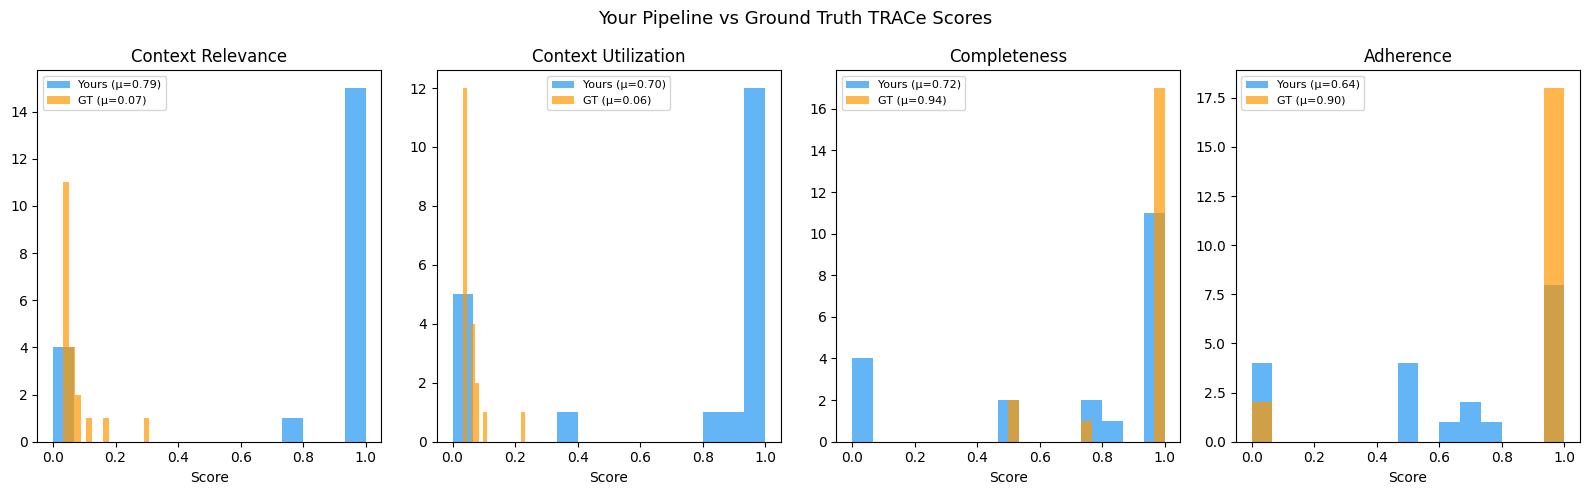

In [20]:
# Visualise comparison
if 'test_df' not in dir() or "my_context_relevance" not in test_df.columns:
    print("⚠️  Cannot visualize: 'my_*' columns not found.")
    print("    Please run Step 1.7 (Run Baseline) first.")
else:
    # ── Resolve the REAL ground-truth column for each metric ──
    # GT columns live in `df` under varied names (gpt3_*, *_score, plain names),
    # NOT in test_df. Re-resolve here so the chart is self-contained.
    def _resolve_gt_col(keywords, exclude=()):
        for c in df.columns:
            lc = c.lower()
            if all(k in lc for k in keywords) and not any(x in lc for x in exclude):
                if pd.to_numeric(df[c], errors="coerce").notna().any():
                    return c
        return None

    metric_pairs = [
        ("my_context_relevance",   _resolve_gt_col(["relevance"]),    "Context Relevance"),
        ("my_context_utilization", _resolve_gt_col(["utilization"]),  "Context Utilization"),
        ("my_completeness",        _resolve_gt_col(["completeness"]), "Completeness"),
        ("my_adherence",           _resolve_gt_col(["adherence"]),    "Adherence"),
    ]

    # Merge the resolved GT columns onto our results so both are aligned per-sample
    gt_cols = [gt for _, gt, _ in metric_pairs if gt is not None]
    plot_df = test_df.merge(df[["question"] + gt_cols], on="question", how="left") \
        if gt_cols else test_df

    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    fig.suptitle("Your Pipeline vs Ground Truth TRACe Scores", fontsize=13)

    for ax, (my_col, gt_col, title) in zip(axes, metric_pairs):
        # Cast to float — some GT columns (e.g. adherence) are boolean, which
        # matplotlib's hist / numpy histogram cannot bin directly.
        my_vals = pd.to_numeric(plot_df[my_col], errors="coerce").dropna().astype(float)
        ax.hist(my_vals, bins=15, alpha=0.7, color="#2196F3",
                label=f"Yours (μ={my_vals.mean():.2f})")
        if gt_col is not None:
            gt_vals = pd.to_numeric(plot_df[gt_col], errors="coerce").dropna().astype(float)
            if len(gt_vals):
                ax.hist(gt_vals, bins=15, alpha=0.7, color="#FF9800",
                        label=f"GT (μ={gt_vals.mean():.2f})")
        ax.set_title(title); ax.set_xlabel("Score"); ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig("phase1_comparison.png", dpi=100, bbox_inches="tight")
    plt.show()


### Step 1.9 — LLM-as-a-Judge (answer quality check)

A final qualitative check on top of the TRACe metrics. An LLM reads the
**question**, the **retrieved context**, our **generated answer**, and the
**reference answer**, then scores three dimensions (1–5) and gives a PASS/FAIL
verdict with a short reason:

- **Faithfulness** — is the answer supported by the retrieved context (no hallucination)?
- **Correctness** — does the answer agree with the reference answer?
- **Completeness** — does it cover the key facts of the reference answer?

> **Judge model — 15 GB T4 reality.** A 14B judge does **not** fit reliably on a
> single T4: even after freeing the 7B generator, the model's fp16 load-time peak
> overflows VRAM (CUDA OOM). So by default (`USE_INDEPENDENT_JUDGE = False`) the
> judge **reuses the already-loaded 7B generator** — reliable, no download, no OOM.
>
> Want an *independent* judge (no self-bias)? Set `USE_INDEPENDENT_JUDGE = True`;
> the default `JUDGE_MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"` is small enough to load
> **alongside** the 7B on a T4. The 14B is stronger but needs ≥24 GB VRAM — only
> then set `FREE_GENERATOR_BEFORE_JUDGE = True` (that releases `generator.model`, so
> **re-run Step 1.4 before generating again**). Depends on `test_df` from Step 1.7.



10:16:57 | RAG_PIPELINE         | INFO     | ================================================================================
10:16:57 | RAG_PIPELINE         | INFO     | LLM-AS-A-JUDGE: Scoring generated answers
10:16:57 | RAG_PIPELINE         | INFO     | ================================================================================
10:16:57 | RAG_PIPELINE         | INFO     | Judging 20 answers with Qwen/Qwen2.5-7B-Instruct (self-judge) ...

LLM-AS-A-JUDGE SUMMARY   (n=20, judge=Qwen/Qwen2.5-7B-Instruct)
  Judge type           : SELF (same model)
  PASS rate            :  75.0%  (15/20)
  Faithfulness         : 4.05 / 5
  Correctness          : 4.05 / 5
  Completeness         : 4.00 / 5

  Sample verdicts:
    [PASS] F5 C5 K5 — The candidate answer accurately calculates and explains the percentage of total future obligations in 2014 from other purchase commitments.
    [PASS] F4 C4 K4 — Accurately captures the range but could specify exact values.
    [PASS] F5 C5 K5 — The candida

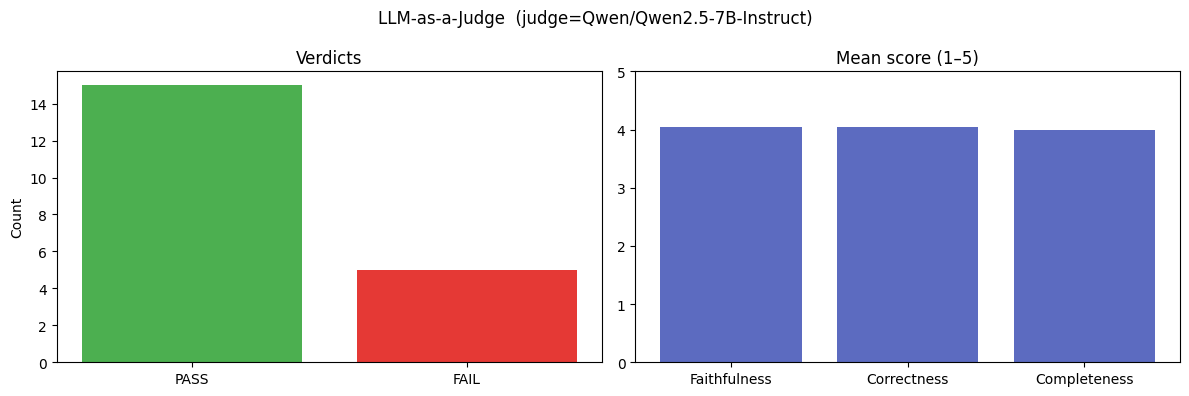

In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1.9 — LLM-AS-A-JUDGE  (holistic answer-quality check on top of TRACe)
# ═══════════════════════════════════════════════════════════════════════════════

import json
import re
import gc

logger.info("="*80)
logger.info("LLM-AS-A-JUDGE: Scoring generated answers")
logger.info("="*80)

# ── Config ────────────────────────────────────────────────────────────────────
# HARDWARE REALITY (single 15 GB T4): a 14B judge does NOT fit reliably. Even after
# freeing the 7B generator, loading a 14B has an fp16 load-time memory peak that
# overflows VRAM → CUDA OutOfMemory. So the SAFE default is a SELF-judge that reuses
# the already-loaded 7B generator: no extra VRAM, no download, no risk of breaking
# the run.
#
#   • USE_INDEPENDENT_JUDGE = False → reuse the 7B generator (reliable, recommended)
#   • USE_INDEPENDENT_JUDGE = True  → load JUDGE_MODEL_ID as a SEPARATE judge:
#       - Qwen/Qwen2.5-3B-Instruct  → small, truly-independent, FITS alongside the
#         7B on a T4 (no self-bias). Good default if you want independence.
#       - Qwen/Qwen2.5-14B-Instruct → stronger, but usually OOMs on a 15 GB T4 even
#         after freeing the generator. Only use it with >=24 GB VRAM.
USE_INDEPENDENT_JUDGE       = False
JUDGE_MODEL_ID              = "Qwen/Qwen2.5-7B-Instruct"   # only used if USE_INDEPENDENT_JUDGE=True (3B also fits a T4)
JUDGE_SAMPLE                = None                          # int to cap, or None = all of test_df
# Free the 7B generator's VRAM before loading the judge. Only needed for a LARGE
# judge; a 3B judge fits alongside the 7B, so leave this False for it.
# NOTE: freeing releases `generator.model` — re-run Step 1.4 before generating again.
FREE_GENERATOR_BEFORE_JUDGE = False


def _free_cuda():
    """Best-effort VRAM cleanup."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# Self-heal: an earlier judge run (or a failed independent-judge load) may have
# freed the generator's VRAM. Reload the 7B so judging always has a working model.
if getattr(generator, "model", None) is None:
    logger.info("Generator VRAM was freed by an earlier run — reloading the 7B...")
    _free_cuda()
    generator = HFGenerator(model_id=generator.model_id,
                            temperature=0.1, max_new_tokens=768)

# Load the (optional) independent judge, with a safe fallback to the 7B generator.
judge_generator = generator
if USE_INDEPENDENT_JUDGE and JUDGE_MODEL_ID != generator.model_id:
    if FREE_GENERATOR_BEFORE_JUDGE and getattr(generator, "model", None) is not None:
        logger.info("Freeing the 7B generator's VRAM to make room for the judge "
                    "(re-run Step 1.4 before generating again)...")
        try:
            del generator.model
            generator.model = None
        except Exception as free_err:
            logger.warning(f"Could not free generator model cleanly: {free_err}")
        _free_cuda()
    try:
        logger.info(f"Loading independent judge model: {JUDGE_MODEL_ID} ...")
        judge_generator = HFGenerator(model_id=JUDGE_MODEL_ID,
                                      temperature=0.0,      # deterministic judging
                                      max_new_tokens=200)
        logger.info("Independent judge loaded ✓")
    except Exception as load_err:
        logger.warning(f"Could not load independent judge ({load_err}); "
                       f"falling back to the 7B self-judge.")
        # Drop the exception (its traceback pins the partially-loaded judge weights
        # in VRAM); then reclaim that memory before reloading the 7B, or the reload
        # will OOM too.
        del load_err
        judge_generator = None
        _free_cuda()
        if getattr(generator, "model", None) is None:
            logger.info("Reloading the 7B generator for self-judging fallback...")
            generator = HFGenerator(model_id=generator.model_id,
                                    temperature=0.1, max_new_tokens=768)
        judge_generator = generator

JUDGE_MODEL = judge_generator.model_id

JUDGE_SYSTEM_PROMPT = """You are a strict, impartial evaluator of financial Q&A answers. \
You are given a QUESTION, the CONTEXT the answer was based on, a REFERENCE ANSWER \
(ground truth), and a CANDIDATE ANSWER to judge.

Score the CANDIDATE ANSWER on three dimensions, each an integer 1-5 (5 = best):
- faithfulness : is every claim supported by the CONTEXT (no hallucination)?
- correctness  : does it agree with the REFERENCE ANSWER (right numbers/facts)?
- completeness : does it cover the key facts of the REFERENCE ANSWER?

Then give an overall verdict: "PASS" if the answer is correct and grounded, else "FAIL".

Respond with ONLY a single JSON object, no other text:
{"faithfulness": <1-5>, "correctness": <1-5>, "completeness": <1-5>, "verdict": "PASS"|"FAIL", "reason": "<one short sentence>"}"""


def _parse_judge_json(raw: str) -> dict:
    """Extract the first JSON object from the model output; fall back safely."""
    match = re.search(r"\{.*\}", raw, flags=re.DOTALL)
    if match:
        try:
            obj = json.loads(match.group(0))
            return {
                "judge_faithfulness": int(obj.get("faithfulness", 0)),
                "judge_correctness":  int(obj.get("correctness", 0)),
                "judge_completeness": int(obj.get("completeness", 0)),
                "judge_verdict":      str(obj.get("verdict", "FAIL")).upper(),
                "judge_reason":       str(obj.get("reason", ""))[:300],
            }
        except (ValueError, TypeError) as e:
            evaluator_logger.warning(f"Judge JSON parse failed: {e}")
    return {
        "judge_faithfulness": 0, "judge_correctness": 0, "judge_completeness": 0,
        "judge_verdict": "FAIL", "judge_reason": "unparseable judge output",
    }


def judge_answer(question: str, context: str, answer: str, reference: str) -> dict:
    """Run one LLM-as-a-Judge evaluation using the (independent) judge model."""
    user_msg = (
        f"QUESTION:\n{question}\n\n"
        f"CONTEXT:\n{context if context else '(no context was retrieved)'}\n\n"
        f"REFERENCE ANSWER:\n{reference if reference else '(none provided)'}\n\n"
        f"CANDIDATE ANSWER:\n{answer}\n\n"
        f"Return the JSON verdict now:"
    )
    messages = [
        {"role": "system", "content": JUDGE_SYSTEM_PROMPT},
        {"role": "user",   "content": user_msg},
    ]
    raw = judge_generator._run(messages, max_new_tokens=200)
    return _parse_judge_json(raw)


# ── Run the judge over test_df ─────────────────────────────────────────────────
if 'test_df' not in dir() or len(test_df) == 0:
    print("⚠️  test_df not found or empty — run Step 1.7 first.")
else:
    judge_df = test_df if JUDGE_SAMPLE is None else test_df.head(JUDGE_SAMPLE)
    logger.info(f"Judging {len(judge_df)} answers with {JUDGE_MODEL} "
                f"({'independent' if judge_generator is not generator else 'self-judge'}) ...")

    # Map each result's question back to its reference (GT) answer in df
    q_to_ref = dict(zip(df["question"], df["response"].astype(str))) if "response" in df.columns else {}

    judge_records = []
    for _, r in judge_df.iterrows():
        reference = q_to_ref.get(r["question"], "")
        try:
            verdict = judge_answer(r["question"], r.get("my_context", ""),
                                   r.get("my_response", ""), reference)
        except Exception as e:
            evaluator_logger.error(f"Judge failed on idx {r.get('idx')}: {e}")
            verdict = {
                "judge_faithfulness": 0, "judge_correctness": 0, "judge_completeness": 0,
                "judge_verdict": "FAIL", "judge_reason": f"judge error: {e}",
            }
        judge_records.append(verdict)

    # Index-safe alignment: judge_df preserves test_df's row index, so assign by
    # index (avoids the cartesian blow-up a merge-on-question would cause if any
    # question string repeats). Un-judged rows (when JUDGE_SAMPLE is set) stay NaN.
    judge_scores = pd.DataFrame(judge_records, index=judge_df.index)
    for col in ["judge_faithfulness", "judge_correctness", "judge_completeness",
                "judge_verdict", "judge_reason"]:
        test_df[col] = judge_scores[col]

    # ── Summary ────────────────────────────────────────────────────────────────
    n = len(judge_scores)
    pass_rate = (judge_scores["judge_verdict"] == "PASS").mean() if n else 0.0
    print(f"\n{'='*60}")
    print(f"LLM-AS-A-JUDGE SUMMARY   (n={n}, judge={JUDGE_MODEL})")
    print(f"{'='*60}")
    print(f"  Judge type           : "
          f"{'INDEPENDENT' if judge_generator is not generator else 'SELF (same model)'}")
    print(f"  PASS rate            : {pass_rate*100:5.1f}%  "
          f"({int((judge_scores['judge_verdict']=='PASS').sum())}/{n})")
    for col, label in [("judge_faithfulness", "Faithfulness"),
                       ("judge_correctness",  "Correctness"),
                       ("judge_completeness", "Completeness")]:
        print(f"  {label:<20} : {judge_scores[col].mean():.2f} / 5")

    print("\n  Sample verdicts:")
    for _, r in judge_scores.head(5).iterrows():
        print(f"    [{r['judge_verdict']:<4}] F{r['judge_faithfulness']} "
              f"C{r['judge_correctness']} K{r['judge_completeness']} — {r['judge_reason']}")

    # ── Save + plot ──────────────────────────────────────────────────────────────
    test_df.to_csv("phase1_with_judge.csv", index=False)
    print(f"\nSaved: phase1_with_judge.csv  ({len(test_df)} rows)")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"LLM-as-a-Judge  (judge={JUDGE_MODEL})", fontsize=12)

    vc = judge_scores["judge_verdict"].value_counts()
    axes[0].bar(vc.index, vc.values, color=["#4CAF50" if v == "PASS" else "#E53935" for v in vc.index])
    axes[0].set_title("Verdicts"); axes[0].set_ylabel("Count")

    dims = ["judge_faithfulness", "judge_correctness", "judge_completeness"]
    axes[1].bar([d.replace("judge_", "").title() for d in dims],
                [judge_scores[d].mean() for d in dims], color="#3F51B5", alpha=0.85)
    axes[1].set_ylim(0, 5); axes[1].set_title("Mean score (1–5)")

    plt.tight_layout()
    plt.savefig("phase1_judge.png", dpi=100, bbox_inches="tight")
    plt.show()


---
## Step 3 — Streamlit UI (interactive RAG playground)

A front-end that lets anyone drive the **exact** EMNLP-2024 pipeline from the browser —
tick strategies on/off, tune knobs, ask a question, and see the answer + TRACe scores +
an LLM-as-a-Judge verdict live.

### Layout

```
┌────────────────────────────────────────────────────────────────────────────┐
│  🏦  RAG for Finance — Best-Practices Playground                            │
├──────────────── Sidebar ─────────────────┬───────────── Main ──────────────┤
│ ⚙️  STRATEGY SELECTION                    │  Question  [ text box .......... ]│
│   Chunking      ▸ sliding_window ▾        │  Context   ● paste  ○ dataset ex.│
│                   semantic / fixed        │  [ documents / passages ........ ]│
│   Retrieval     ▸ Hybrid ▾                │                     [  ▶ Run RAG ]│
│                   Dense only / BM25 only  │                                   │
│   ☑ HyDE   ☑ monoT5 rerank                │  ── Answer ─────────────────────  │
│   ☑ Reverse repack  ☑ Recomp compress     │  Apple's Q4-19 net revenue was …  │
│   ☑ Query classifier                      │                                   │
│                                           │  ── TRACe scores ───────────────  │
│ 🎛️  PARAMETERS                            │  ctx-relevance  ███████░ 0.88     │
│   top_k 4  fetch_k 15                      │  ctx-utilisation██████░░ 0.75     │
│   chunk 512  overlap 128                   │  completeness   ███████░ 0.90     │
│   temperature 0.1  max_tokens 768          │  adherence      ████████ 0.95     │
│                                           │  avg_trace      ███████░ 0.87     │
│ 🧪  EVALUATION                            │                                   │
│   ☑ TRACe metrics                          │  ── LLM-as-a-Judge ─ [PASS] ────  │
│   ☑ LLM-as-a-Judge                         │  F5 · C5 · K4 — grounded & correct│
│   (optional) reference answer             │                                   │
│                                           │  ▸ Retrieved context (4 chunks)   │
│                                           │  ▸ Pipeline trace  ⏱ 3.4s         │
└───────────────────────────────────────────┴───────────────────────────────────┘
```

### Strategy selection (all wired to real pipeline objects)
- **Chunking**: `sliding_window` · `semantic` · `fixed`
- **Retrieval mode**: `Hybrid (BM25+Dense)` · `Dense only` · `BM25 only`
- **Toggles**: HyDE · monoT5 rerank · reverse repack · Recomp compression · query classifier
- **Knobs**: `top_k`, `fetch_k`, `chunk_size`, `overlap`, `temperature`, `max_new_tokens`

### Nice-to-have features worth adding
- **A/B compare** — run two strategy configs side-by-side and diff the TRACe scores.
- **Config presets** — "Paper best-practice", "Fast/cheap", "BM25 baseline" one-click.
- **Dataset examples** — dropdown pre-filled from FinQA rows (exported below) with the GT answer.
- **Source highlighting** — show which retrieved sentences the answer is grounded in.
- **Latency / token meter** — per-stage timing + tokens, so users see the HyDE/LLM cost.
- **Batch eval** — run N dataset samples and chart average TRACe per strategy.
- **Chat history + download** — keep a session log and export answers+scores to CSV.
- **File upload** — drop a PDF/10-K and RAG over it (add a PDF text extractor).

> The next cell writes a self-contained `app.py`. The pipeline classes are exported
> straight from this notebook, so the UI always matches your code.


In [22]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 3.0 — FREE THE NOTEBOOK'S GPU MEMORY  (run this BEFORE launching the app)
# The Streamlit app (Step 3.2) loads its OWN copy of the models in a separate
# process. On a single T4 that OOMs if this kernel is still holding the 7B +
# embedder + monoT5 + NLI. This releases them so the app gets the whole GPU.
# (Equivalent alternative: Run → Restart & clear kernel, then run only 3.1 + 3.2.)
# ═══════════════════════════════════════════════════════════════════════════════
import gc, torch

_to_free = ["generator", "judge_generator", "embedder", "reranker", "evaluator",
            "hyde", "compressor", "bm25_ret", "dense_ret", "hybrid_ret",
            "sample_store", "query_classifier", "OllamaGenerator"]

for _name in _to_free:
    _obj = globals().get(_name)
    if _obj is not None:
        for _attr in ("model", "tokenizer"):        # drop nested HF/ST weights first
            if hasattr(_obj, _attr):
                try:
                    setattr(_obj, _attr, None)
                except Exception:
                    pass
        globals()[_name] = None

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    free_b, total_b = torch.cuda.mem_get_info()
    print(f"GPU free: {free_b/1024**3:.2f} / {total_b/1024**3:.2f} GB")
    if free_b / 1024**3 < 12:
        print("⚠️  Less than ~12 GB free — if the app still OOMs, do "
              "Run → Restart & clear kernel, then run ONLY Step 3.1 + Step 3.2.")
print("✓ Notebook VRAM released — now run Step 3.1, then Step 3.2.")


GPU free: 14.41 / 14.56 GB
✓ Notebook VRAM released — now run Step 3.1, then Step 3.2.


In [23]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 3.1 — WRITE THE STREAMLIT APP  (self-contained `app.py`)
# NOTE: we DON'T use inspect.getsource() — on Kaggle the pipeline classes live in
# __main__ (no source file), so inspect raises "source code not available".
# Instead the pipeline code is embedded here as a raw string, so this cell is fully
# standalone: it writes app.py even after a kernel restart, with no other cells run.
# ═══════════════════════════════════════════════════════════════════════════════

# 1) Export a few dataset rows so the UI has ready-made examples (optional; skipped
#    gracefully if `df` isn't in memory — the app falls back to starter questions).
try:
    _cols = [c for c in ["question", "documents", "context", "response"] if c in df.columns]
    df[_cols].head(50).to_json("finqa_examples.json", orient="records")
    print("✓ Exported 50 example rows → finqa_examples.json")
except Exception as _e:
    print(f"(no dataset examples exported: {_e})")


_IMPORTS = '''\
# ══════════════════════════════════════════════════════════════════════════════
# AUTO-GENERATED by the RAG notebook — Streamlit front-end for the EMNLP-2024 pipeline
# ══════════════════════════════════════════════════════════════════════════════
import streamlit as st
import numpy as np, pandas as pd, torch, re, json, gc, time, logging, os
import faiss
from typing import List, Tuple, Dict
from sentence_transformers import SentenceTransformer, CrossEncoder
from rank_bm25 import BM25Okapi
from transformers import (AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig,
                          T5Tokenizer, T5ForConditionalGeneration)

logging.basicConfig(level=logging.WARNING)
logger = embedder_logger = retriever_logger = generator_logger = evaluator_logger = logging.getLogger("rag")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
'''


# ── Pipeline code embedded verbatim (raw string → backslashes/regex preserved) ──
_PIPELINE_SRC = r'''
# ══ Constants ══
MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"

GROUNDING_SYSTEM_PROMPT = """You are a precise financial Q&A assistant. \
Your ONLY job is to extract answers directly from the provided context.

STRICT RULES:
1. Read the context carefully before answering.
2. Your answer must be built ONLY from facts in the context — no outside knowledge.
3. If the answer requires a calculation (%, ratio, difference), show the calculation with specific numbers from the context.
4. If the context does NOT contain enough information, say exactly:
   "The context does not contain information to answer this question."
5. Be THOROUGH — include ALL relevant numbers, percentages, dates, and data points from the context that relate to the question. Do not omit details.
6. Do NOT start with phrases like "Based on the context" or "According to the provided information".
7. When multiple data points are relevant, list them all.
"""

HYDE_SYSTEM_PROMPT = """You are a financial domain expert. Write a short, factual \
passage (3-5 sentences) that would plausibly appear in a company's financial \
report or filing and that directly answers the user's question. Include concrete \
figures, line items, and terminology. Do not say you are unsure — write it as if \
it were an authentic excerpt."""


class TextChunker:
    """Splits long text into overlapping chunks (sliding_window | semantic | fixed)."""

    def __init__(self, strategy: str = "sliding_window",
                 chunk_size: int = 512, overlap: int = 64):
        self.strategy   = strategy
        self.chunk_size = chunk_size * 4
        self.overlap    = overlap * 4
        self._dispatch  = {
            "sliding_window": self._sliding_window,
            "semantic":       self._semantic,
            "fixed":          self._fixed,
        }

    def chunk(self, text: str) -> List[str]:
        if not text or not text.strip():
            return []
        fn = self._dispatch.get(self.strategy, self._sliding_window)
        return [c.strip() for c in fn(text.strip()) if c.strip()]

    def _sliding_window(self, text: str) -> List[str]:
        chunks = []
        step = self.chunk_size - self.overlap
        start = 0
        while start < len(text):
            end = start + self.chunk_size
            chunk = text[start:end]
            if end < len(text):
                last_period_pos = chunk.rfind(". ")
                if last_period_pos > self.chunk_size // 2:
                    chunk = chunk[:last_period_pos + 1]
            chunks.append(chunk)
            start += step
        return chunks

    def _semantic(self, text: str) -> List[str]:
        sentences = re.split(r'(?<=[.!?])\s+', text)
        chunks = []
        current = ""
        for sent in sentences:
            if len(current) + len(sent) < self.chunk_size:
                current += sent + " "
            else:
                if current:
                    chunks.append(current.strip())
                current = sent + " "
        if current:
            chunks.append(current.strip())
        return chunks

    def _fixed(self, text: str) -> List[str]:
        return [text[i:i+self.chunk_size]
                for i in range(0, len(text), self.chunk_size)]


class Embedder:
    """Wraps BAAI/llm-embedder for encoding queries and passages."""

    INSTRUCTIONS = {
        "query": "Represent this query for retrieving relevant documents: ",
        "key":   "Represent this document for retrieval: ",
    }

    def __init__(self, model_name: str = "BAAI/llm-embedder",
                 device: str = "cpu", batch_size: int = 32):
        self.model_name = model_name
        self.device = device
        self.batch_size = batch_size
        self.use_instructions = "llm-embedder" in model_name.lower()
        embedder_logger.info(f"Initializing Embedder: model={model_name}, device={device}")
        try:
            self.model = SentenceTransformer(model_name, device=device)
            self.dim = self.model.get_sentence_embedding_dimension()
        except Exception as e:
            embedder_logger.error(f"Failed to load model: {e}")
            raise

    def _encode(self, texts: List[str], show_progress: bool = False) -> np.ndarray:
        return self.model.encode(
            texts, batch_size=self.batch_size, show_progress_bar=show_progress,
            normalize_embeddings=True, convert_to_numpy=True,
        )

    def encode(self, texts: List[str], show_progress: bool = False) -> np.ndarray:
        return self._encode(texts, show_progress)

    def encode_passages(self, texts: List[str], show_progress: bool = False) -> np.ndarray:
        if self.use_instructions:
            texts = [self.INSTRUCTIONS["key"] + t for t in texts]
        return self._encode(texts, show_progress)

    def encode_query(self, query: str) -> np.ndarray:
        if self.use_instructions:
            prefixed = self.INSTRUCTIONS["query"] + query
        else:
            prefixed = f"Represent this sentence for searching relevant passages: {query}"
        return self._encode([prefixed])[0]


class FAISSVectorStore:
    """FAISS flat index — exact cosine similarity on normalised embeddings."""

    def __init__(self, dim: int):
        self.dim      = dim
        self.index    = faiss.IndexFlatIP(dim)
        self.texts    = []
        self.metadata = []

    def add(self, chunks, embeddings, metadata=None):
        assert len(chunks) == len(embeddings)
        self.index.add(embeddings.astype(np.float32))
        self.texts.extend(chunks)
        self.metadata.extend(metadata if metadata else [{}] * len(chunks))

    def search(self, query_emb, top_k: int = 5):
        if self.index.ntotal == 0:
            return []
        q = query_emb.reshape(1, -1).astype(np.float32)
        scores, indices = self.index.search(q, min(top_k, self.index.ntotal))
        return [(self.texts[i], float(s), self.metadata[i])
                for s, i in zip(scores[0], indices[0]) if i >= 0]

    def __len__(self):
        return self.index.ntotal


def build_vector_store(chunks, embedder, metadata=None):
    embs  = embedder.encode_passages(chunks, show_progress=False)
    store = FAISSVectorStore(dim=embedder.dim)
    store.add(chunks, embs, metadata)
    return store


class QueryClassifier:
    """Decides whether a query NEEDS retrieval (heuristic stand-in)."""

    _NO_RETRIEVAL = re.compile(
        r"^\s*(hi|hello|hey|thanks|thank you|good (morning|evening|afternoon))\b",
        re.IGNORECASE,
    )
    _PURE_ARITHMETIC = re.compile(r"^\s*[\d\s\+\-\*/\.\(\)%]+\s*=?\s*\??\s*$")

    def needs_retrieval(self, query: str) -> bool:
        q = (query or "").strip()
        if not q:
            return False
        if self._NO_RETRIEVAL.match(q):
            return False
        if self._PURE_ARITHMETIC.match(q):
            return False
        return True


class HyDETransformer:
    """Hypothetical Document Embeddings (HyDE)."""

    def __init__(self, generator):
        self.generator = generator

    def augment(self, query: str) -> str:
        try:
            hypo = self.generator.generate_hyde(query)
        except Exception:
            return query
        if not hypo:
            return query
        return f"{query}\n{hypo}"


class MonoT5Reranker:
    """monoT5 cross-encoder reranker."""

    def __init__(self, model_name: str = "castorini/monot5-base-msmarco-10k",
                 device: str = "cpu", batch_size: int = 16):
        self.device     = device
        self.batch_size = batch_size
        self.tokenizer  = T5Tokenizer.from_pretrained(model_name)
        self.model      = T5ForConditionalGeneration.from_pretrained(model_name).to(device).eval()
        self.true_id  = self.tokenizer.encode("true",  add_special_tokens=False)[0]
        self.false_id = self.tokenizer.encode("false", add_special_tokens=False)[0]

    def rerank(self, query: str, chunks, top_k: int = 5):
        if not chunks:
            return []
        scores = []
        for i in range(0, len(chunks), self.batch_size):
            batch   = chunks[i:i + self.batch_size]
            prompts = [f"Query: {query} Document: {c} Relevant:" for c in batch]
            inputs  = self.tokenizer(prompts, return_tensors="pt", padding=True,
                                     truncation=True, max_length=512).to(self.device)
            decoder_input_ids = torch.full(
                (len(batch), 1), self.model.config.decoder_start_token_id,
                dtype=torch.long, device=self.device,
            )
            with torch.no_grad():
                logits = self.model(**inputs, decoder_input_ids=decoder_input_ids).logits[:, 0, :]
                tf     = logits[:, [self.false_id, self.true_id]]
                probs  = torch.softmax(tf, dim=1)[:, 1]
            scores.extend(probs.detach().cpu().tolist())
        ranked = sorted(zip(chunks, scores), key=lambda x: x[1], reverse=True)[:top_k]
        return [(c, float(s)) for c, s in ranked]


class BM25Retriever:
    """Sparse keyword retrieval — best for exact numbers, names, acronyms."""

    def __init__(self, chunks):
        self.chunks = chunks
        self.bm25   = BM25Okapi([doc.lower().split() for doc in chunks])

    def search(self, query: str, top_k: int = 5):
        scores = self.bm25.get_scores(query.lower().split())
        top_indices = np.argsort(scores)[::-1][:top_k]
        return [(self.chunks[i], float(scores[i])) for i in top_indices]


class DenseRetriever:
    """Dense semantic retrieval using embeddings."""

    def __init__(self, store, embedder):
        self.store    = store
        self.embedder = embedder

    def search(self, query: str, top_k: int = 5):
        query_emb = self.embedder.encode_query(query)
        results = self.store.search(query_emb, top_k)
        return [(text, score) for text, score, _ in results]


class HybridRetriever:
    """Hybrid BM25 + Dense via RRF, with optional HyDE + monoT5 rerank."""

    def __init__(self, bm25_ret, dense_ret, alpha: float = 0.5,
                 reranker=None, hyde=None):
        self.bm25_ret  = bm25_ret
        self.dense_ret = dense_ret
        self.alpha     = alpha
        self.reranker  = reranker
        self.hyde      = hyde

    def search(self, query: str, top_k: int = 5, fetch_k: int = 15):
        bm25_results = self.bm25_ret.search(query, top_k=fetch_k)
        dense_query = self.hyde.augment(query) if self.hyde is not None else query
        dense_results = self.dense_ret.search(dense_query, top_k=fetch_k)

        rrf = {}
        k = 60
        for rank, (chunk, _) in enumerate(bm25_results, 1):
            rrf[chunk] = rrf.get(chunk, 0) + 1.0 / (k + rank)
        for rank, (chunk, _) in enumerate(dense_results, 1):
            rrf[chunk] = rrf.get(chunk, 0) + 1.0 / (k + rank)

        sorted_rrf = sorted(rrf.items(), key=lambda x: x[1], reverse=True)
        if self.reranker is not None:
            pool = [chunk for chunk, _ in sorted_rrf[:fetch_k]]
            return self.reranker.rerank(query, pool, top_k=top_k)
        return [(chunk, score) for chunk, score in sorted_rrf[:top_k]]


def reverse_repack(ranked_chunks):
    """Ascending relevance order — most relevant chunk closest to the query."""
    return list(reversed(ranked_chunks))


class ContextCompressor:
    """Recomp-style extractive context compressor."""

    def __init__(self, embedder, max_sentences: int = 10, min_score: float = 0.2):
        self.embedder      = embedder
        self.max_sentences = max_sentences
        self.min_score     = min_score

    @staticmethod
    def _split_sentences(text: str):
        text = re.sub(r"\s+", " ", str(text)).strip()
        if not text:
            return []
        sents = re.split(r"(?<=[.!?])\s+(?=[A-Z0-9$(])", text)
        return [s.strip() for s in sents if len(s.strip()) > 10]

    def compress(self, query: str, chunks):
        sentences, order = [], []
        for ci, chunk in enumerate(chunks):
            for sent in self._split_sentences(chunk):
                sentences.append(sent)
                order.append(ci)
        if not sentences:
            return chunks
        q_emb  = self.embedder.encode_query(query)
        s_embs = self.embedder.encode_passages(sentences)
        sims   = s_embs @ q_emb
        ranked_idx = np.argsort(sims)[::-1]
        keep = [i for i in ranked_idx if sims[i] >= self.min_score][: self.max_sentences]
        if not keep:
            keep = list(ranked_idx[: self.max_sentences])
        keep_sorted = sorted(keep)
        return [sentences[i] for i in keep_sorted]


class HFGenerator:
    """LLM answer generation using a HuggingFace model (4-bit on GPU)."""

    def __init__(self, model_id: str = MODEL_ID, temperature: float = 0.1,
                 max_new_tokens: int = 768, device: str = None):
        self.model_id       = model_id
        self.temperature    = temperature
        self.max_new_tokens = max_new_tokens
        self.device         = device or ("cuda" if torch.cuda.is_available() else "cpu")

        if self.device == "cuda":
            bnb_config = BitsAndBytesConfig(
                load_in_4bit=True, bnb_4bit_quant_type="nf4",
                bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True,
            )
            model_kwargs = dict(quantization_config=bnb_config, device_map="auto",
                                trust_remote_code=True)
        else:
            model_kwargs = dict(torch_dtype=torch.float32, device_map="cpu",
                                trust_remote_code=True)

        self.tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
        self.model = AutoModelForCausalLM.from_pretrained(model_id, **model_kwargs)
        self.model.eval()

    def _clean_answer(self, text: str) -> str:
        preambles = [
            r"^Based on the (provided )?context[,\s]+",
            r"^According to the (provided |given )?context[,\s]+",
            r"^From the context[,\s]+",
            r"^The context (states|says|indicates|shows)[,\s]+",
            r"^As (stated|mentioned|indicated) in the context[,\s]+",
            r"^Looking at the context[,\s]+",
        ]
        for pattern in preambles:
            text = re.sub(pattern, "", text, flags=re.IGNORECASE)
        return text.strip()

    def _run(self, messages, max_new_tokens: int) -> str:
        try:
            text = self.tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True,
            )
        except Exception:
            text = "\n\n".join(m["content"] for m in messages) + "\nAnswer:"
        inputs = self.tokenizer(text, return_tensors="pt", truncation=True,
                                max_length=8192).to(self.device)
        input_len = inputs["input_ids"].shape[1]
        with torch.no_grad():
            outputs = self.model.generate(
                **inputs, max_new_tokens=max_new_tokens,
                temperature=max(self.temperature, 1e-6),
                do_sample=self.temperature > 0, repetition_penalty=1.1,
                pad_token_id=self.tokenizer.eos_token_id,
            )
        generated_ids = outputs[0][input_len:]
        return self.tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

    def generate_hyde(self, query: str, max_new_tokens: int = 200) -> str:
        messages = [
            {"role": "system", "content": HYDE_SYSTEM_PROMPT},
            {"role": "user",   "content": f"Question: {query}\n\nHypothetical passage:"},
        ]
        try:
            return self._run(messages, max_new_tokens)
        except Exception:
            return ""

    def generate(self, query: str, context_chunks, verbose: bool = False) -> str:
        context_str = "\n\n".join(context_chunks)
        messages = [
            {"role": "system", "content": GROUNDING_SYSTEM_PROMPT},
            {"role": "user",   "content": (
                f"Context:\n{context_str}\n\n"
                f"Question: {query}\n\n"
                f"Provide a thorough answer using ALL relevant details from the context:"
            )},
        ]
        answer = self._run(messages, self.max_new_tokens)
        return self._clean_answer(answer)


class TRACeEvaluator:
    """Computes all 4 TRACe metrics using an NLI cross-encoder."""

    def __init__(self, model_name: str = "cross-encoder/nli-deberta-v3-base",
                 threshold: float = 0.5, device: str = "cpu"):
        self.model          = CrossEncoder(model_name, device=device, max_length=512)
        self.threshold      = threshold
        self.entailment_idx = 2

    def _split_sentences(self, text: str):
        text = re.sub(r'\s+', ' ', str(text)).strip()
        if not text:
            return []
        sents = re.split(r'(?<=[.!?])\s+(?=[A-Z0-9$(])', text)
        return [s.strip() for s in sents if len(s.strip()) > 10]

    def _batch_entailment(self, pairs):
        if not pairs:
            return []
        scores = self.model.predict(pairs, apply_softmax=True, batch_size=64)
        return [float(s[self.entailment_idx]) for s in scores]

    def _entail_matrix(self, premises, hypotheses):
        if not premises or not hypotheses:
            return np.zeros((len(premises), len(hypotheses)), dtype=float)
        pairs  = [(p, h) for p in premises for h in hypotheses]
        scores = self._batch_entailment(pairs)
        return np.array(scores, dtype=float).reshape(len(premises), len(hypotheses))

    def evaluate(self, query: str, context: str, response: str, reference: str = None):
        c_sents = self._split_sentences(context)
        r_sents = self._split_sentences(response)
        a_sents = self._split_sentences(reference) if reference else []
        t       = self.threshold

        M_cr = self._entail_matrix(c_sents, r_sents)
        if r_sents and c_sents:
            support   = M_cr.max(axis=0)
            adherence = float(np.mean(support >= t))
        else:
            adherence = 0.0

        ref_for_rel = a_sents if a_sents else self._split_sentences(query) or [query]
        M_ca = self._entail_matrix(c_sents, ref_for_rel)
        if c_sents:
            rel_per_ctx       = M_ca.max(axis=1)
            relevant_mask     = rel_per_ctx >= t
            context_relevance = float(np.mean(relevant_mask))
        else:
            relevant_mask     = np.zeros(0, dtype=bool)
            context_relevance = 0.0

        M_rc = self._entail_matrix(r_sents, c_sents)
        if c_sents and r_sents:
            used_per_ctx = M_rc.max(axis=0) >= t
            if relevant_mask.any():
                context_utilization = float(np.mean(used_per_ctx[relevant_mask]))
            else:
                context_utilization = float(np.mean(used_per_ctx))
        else:
            context_utilization = 0.0

        if a_sents and r_sents:
            M_ra         = self._entail_matrix(r_sents, a_sents)
            cover        = M_ra.max(axis=0)
            completeness = float(np.mean(cover >= t))
        elif not a_sents:
            completeness = adherence
        else:
            completeness = 0.0

        scores = {
            "context_relevance":   context_relevance,
            "context_utilization": context_utilization,
            "completeness":        completeness,
            "adherence":           adherence,
        }
        scores["avg_trace"] = float(np.mean(list(scores.values())))
        return scores
'''


_UI = r'''
# ══════════════════════════════════════════════════════════════════════════════
# LLM-as-a-Judge (self-judge, reuses the loaded generator)
# ══════════════════════════════════════════════════════════════════════════════
JUDGE_SYSTEM_PROMPT = """You are a strict, impartial evaluator of financial Q&A answers. \
You are given a QUESTION, the CONTEXT the answer was based on, a REFERENCE ANSWER \
(ground truth), and a CANDIDATE ANSWER to judge.

Score the CANDIDATE ANSWER on three dimensions, each an integer 1-5 (5 = best):
- faithfulness : is every claim supported by the CONTEXT (no hallucination)?
- correctness  : does it agree with the REFERENCE ANSWER (right numbers/facts)?
- completeness : does it cover the key facts of the REFERENCE ANSWER?

Then give an overall verdict: "PASS" if the answer is correct and grounded, else "FAIL".

Respond with ONLY a single JSON object, no other text:
{"faithfulness": <1-5>, "correctness": <1-5>, "completeness": <1-5>, "verdict": "PASS"|"FAIL", "reason": "<one short sentence>"}"""


def _parse_judge_json(raw: str) -> dict:
    m = re.search(r"\{.*\}", raw, flags=re.DOTALL)
    if m:
        try:
            o = json.loads(m.group(0))
            return {"faithfulness": int(o.get("faithfulness", 0)),
                    "correctness": int(o.get("correctness", 0)),
                    "completeness": int(o.get("completeness", 0)),
                    "verdict": str(o.get("verdict", "FAIL")).upper(),
                    "reason": str(o.get("reason", ""))[:300]}
        except (ValueError, TypeError):
            pass
    return {"faithfulness": 0, "correctness": 0, "completeness": 0,
            "verdict": "FAIL", "reason": "unparseable judge output"}


def run_judge(gen, question, context, answer, reference):
    user = (f"QUESTION:\n{question}\n\nCONTEXT:\n{context or '(no context retrieved)'}\n\n"
            f"REFERENCE ANSWER:\n{reference or '(none provided)'}\n\n"
            f"CANDIDATE ANSWER:\n{answer}\n\nReturn the JSON verdict now:")
    raw = gen._run([{"role": "system", "content": JUDGE_SYSTEM_PROMPT},
                    {"role": "user", "content": user}], max_new_tokens=200)
    return _parse_judge_json(raw)


# ══════════════════════════════════════════════════════════════════════════════
# Load the pipeline ONCE (cached across reruns)
# ══════════════════════════════════════════════════════════════════════════════
class _MiniLMReranker:
    """Fallback reranker if monoT5 fails to load."""
    def __init__(self, device):
        self.model = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2", device=device, max_length=512)
    def rerank(self, query, chunks, top_k=5):
        if not chunks:
            return []
        s = 1.0 / (1.0 + np.exp(-np.asarray(self.model.predict([(query, c) for c in chunks]), dtype=float)))
        return [(c, float(x)) for c, x in sorted(zip(chunks, s), key=lambda z: z[1], reverse=True)[:top_k]]


@st.cache_resource(show_spinner="Loading models (first run downloads weights)…")
def load_pipeline():
    embedder = Embedder(model_name="BAAI/llm-embedder", device=DEVICE)
    try:
        reranker = MonoT5Reranker(device=DEVICE)
    except Exception:
        reranker = _MiniLMReranker(DEVICE)
    generator = HFGenerator(model_id=MODEL_ID, temperature=0.1, max_new_tokens=768)
    return {
        "embedder": embedder,
        "reranker": reranker,
        "generator": generator,
        "hyde": HyDETransformer(generator),
        "compressor": ContextCompressor(embedder, max_sentences=10, min_score=0.2),
        "evaluator": TRACeEvaluator(model_name="cross-encoder/nli-deberta-v3-base",
                                    threshold=0.5, device=DEVICE),
        "qc": QueryClassifier(),
    }


@st.cache_data
def load_examples():
    try:
        return pd.read_json("finqa_examples.json")
    except Exception:
        return pd.DataFrame()


# ══════════════════════════════════════════════════════════════════════════════
# Run one query through the (configurable) pipeline
# ══════════════════════════════════════════════════════════════════════════════
def run_query(P, question, docs, cfg):
    t0, trace = time.time(), []
    chunker = TextChunker(strategy=cfg["chunk_strategy"],
                          chunk_size=cfg["chunk_size"], overlap=cfg["overlap"])
    chunks = []
    for d in docs:
        chunks.extend(chunker.chunk(d))
    trace.append(f"Chunked → {len(chunks)} pieces ({cfg['chunk_strategy']})")
    if not chunks:
        return {"error": "No chunks were produced — please provide some context."}

    do_retrieve = True
    if cfg["use_classifier"]:
        do_retrieve = P["qc"].needs_retrieval(question)
        trace.append(f"Query classifier → {'RETRIEVE' if do_retrieve else 'SKIP retrieval'}")

    retrieved = []
    if do_retrieve:
        store = build_vector_store(chunks, P["embedder"])
        bm25, dense = BM25Retriever(chunks), DenseRetriever(store, P["embedder"])
        reranker = P["reranker"] if cfg["use_reranker"] else None
        hyde = P["hyde"] if cfg["use_hyde"] else None

        if cfg["retrieval_mode"].startswith("Hybrid"):
            res = HybridRetriever(bm25, dense, reranker=reranker, hyde=hyde).search(
                question, top_k=cfg["top_k"], fetch_k=cfg["fetch_k"])
        else:
            if cfg["retrieval_mode"].startswith("Dense"):
                q = hyde.augment(question) if hyde else question
                res = dense.search(q, top_k=cfg["fetch_k"])
            else:  # BM25 only
                res = bm25.search(question, top_k=cfg["fetch_k"])
            if reranker:
                res = reranker.rerank(question, [c for c, _ in res], top_k=cfg["top_k"])
            else:
                res = res[:cfg["top_k"]]

        ranked = [t for t, _ in res]
        trace.append(f"Retrieved {len(ranked)} chunks — {cfg['retrieval_mode']}"
                     f"{' + HyDE' if hyde else ''}{' + monoT5' if reranker else ''}")
        if cfg["use_repack"]:
            ranked = reverse_repack(ranked)
            trace.append("Reverse-repacked (most relevant nearest the question)")
        retrieved = P["compressor"].compress(question, ranked) if cfg["use_compress"] else ranked
        if cfg["use_compress"]:
            trace.append(f"Recomp compression → {len(retrieved)} sentences")
    else:
        trace.append("Retrieval skipped — answering from the model directly")

    P["generator"].temperature = cfg["temperature"]
    P["generator"].max_new_tokens = cfg["max_new_tokens"]
    answer = P["generator"].generate(question, retrieved)
    trace.append(f"Generated answer ({len(answer)} chars)")

    scores = None
    if cfg["run_trace"]:
        scores = P["evaluator"].evaluate(question, "\n\n".join(retrieved), answer,
                                         reference=(cfg.get("reference") or None))
        trace.append("TRACe evaluated")

    verdict = None
    if cfg["run_judge"]:
        verdict = run_judge(P["generator"], question, "\n\n".join(retrieved),
                            answer, cfg.get("reference") or "")
        trace.append("LLM-as-a-Judge scored")

    return {"answer": answer, "chunks": retrieved, "scores": scores,
            "verdict": verdict, "trace": trace, "latency": time.time() - t0}


# ══════════════════════════════════════════════════════════════════════════════
# UI
# ══════════════════════════════════════════════════════════════════════════════
st.set_page_config(page_title="RAG for Finance", page_icon="🏦", layout="wide")
st.title("🏦 RAG for Finance — Best-Practices Playground")
st.caption("EMNLP-2024 pipeline: classify → hybrid+HyDE → monoT5 → repack → Recomp → Qwen2.5-7B → TRACe")

TYPE_MY_OWN = "✏️ Type my own question…"
FALLBACK_QUESTIONS = [
    "What was the net revenue and how did it change year over year?",
    "What was the operating income for the quarter?",
    "How large was the announced stock buyback?",
    "What drove the year-over-year revenue growth?",
]

PRESETS = {
    "Paper best-practice": dict(chunk_strategy="sliding_window", retrieval_mode="Hybrid (BM25 + Dense)",
                                use_hyde=True, use_reranker=True, use_repack=True,
                                use_compress=True, use_classifier=True, top_k=4, fetch_k=15),
    "Fast / cheap":        dict(chunk_strategy="fixed", retrieval_mode="Dense only",
                                use_hyde=False, use_reranker=False, use_repack=False,
                                use_compress=False, use_classifier=True, top_k=3, fetch_k=8),
    "BM25 baseline":       dict(chunk_strategy="fixed", retrieval_mode="BM25 only",
                                use_hyde=False, use_reranker=False, use_repack=False,
                                use_compress=False, use_classifier=False, top_k=4, fetch_k=15),
}

with st.sidebar:
    st.header("⚙️ Strategy selection")
    preset = st.selectbox("Preset", ["Custom", *PRESETS.keys()], index=1)
    d = PRESETS.get(preset, PRESETS["Paper best-practice"])

    chunk_strategy = st.selectbox("Chunking", ["sliding_window", "semantic", "fixed"],
                                  index=["sliding_window", "semantic", "fixed"].index(d["chunk_strategy"]))
    retrieval_mode = st.radio("Retrieval mode",
                              ["Hybrid (BM25 + Dense)", "Dense only", "BM25 only"],
                              index=["Hybrid (BM25 + Dense)", "Dense only", "BM25 only"].index(d["retrieval_mode"]))
    c1, c2 = st.columns(2)
    use_hyde       = c1.checkbox("HyDE", d["use_hyde"])
    use_reranker   = c2.checkbox("monoT5 rerank", d["use_reranker"])
    use_repack     = c1.checkbox("Reverse repack", d["use_repack"])
    use_compress   = c2.checkbox("Recomp compress", d["use_compress"])
    use_classifier = c1.checkbox("Query classifier", d["use_classifier"])

    st.header("🎛️ Parameters")
    top_k       = st.slider("top_k", 1, 10, d["top_k"])
    fetch_k     = st.slider("fetch_k", 5, 30, d["fetch_k"])
    chunk_size  = st.slider("chunk_size (tokens)", 128, 1024, 512, step=64)
    overlap     = st.slider("overlap (tokens)", 0, 256, 128, step=32)
    temperature = st.slider("temperature", 0.0, 1.0, 0.1, step=0.1)
    max_tokens  = st.slider("max_new_tokens", 128, 1024, 768, step=64)

    st.header("🧪 Evaluation")
    run_trace = st.checkbox("TRACe metrics", True)
    run_judge = st.checkbox("LLM-as-a-Judge", False)

P = load_pipeline()
examples = load_examples()

left, right = st.columns([1, 1])
with left:
    src = st.radio("Context source", ["Paste your own", "Dataset example"], horizontal=True)
    ref_answer = ""
    if src == "Dataset example" and len(examples):
        q_labels = [str(q) for q in examples["question"].astype(str).tolist()]
        q_pick = st.selectbox("Question", q_labels + [TYPE_MY_OWN], index=0)
        if q_pick == TYPE_MY_OWN:
            question = st.text_input("Your question", "")
            context_text = st.text_area("Context / documents (blank line = new passage)", "", height=220)
        else:
            row = examples.iloc[q_labels.index(q_pick)]
            question = q_pick
            docs_val = row["documents"] if isinstance(row.get("documents"), list) else [str(row.get("context", ""))]
            context_text = st.text_area("Context / documents", "\n\n".join(map(str, docs_val)), height=220)
            ref_answer = str(row.get("response", ""))
            st.caption(f"Ground-truth answer: {ref_answer[:200]}")
    else:
        q_pick = st.selectbox("Question", FALLBACK_QUESTIONS + [TYPE_MY_OWN], index=0)
        question = st.text_input("Your question", "") if q_pick == TYPE_MY_OWN else q_pick
        context_text = st.text_area("Context / documents (paste passages, blank line = new passage)",
                                    "Net revenue was $2.74 billion in Q4 2019, up from $2.13 billion a year earlier.\n\n"
                                    "The company announced a $50 billion stock buyback and operating income of $500 million.",
                                    height=220)
    ref_answer = st.text_input("Reference answer (optional, for completeness/judge)", ref_answer)
    go = st.button("▶ Run RAG", type="primary", use_container_width=True)

if go:
    docs = [p.strip() for p in re.split(r"\n\s*\n", context_text) if p.strip()]
    cfg = dict(chunk_strategy=chunk_strategy, retrieval_mode=retrieval_mode,
               use_hyde=use_hyde, use_reranker=use_reranker, use_repack=use_repack,
               use_compress=use_compress, use_classifier=use_classifier,
               top_k=top_k, fetch_k=fetch_k, chunk_size=chunk_size, overlap=overlap,
               temperature=temperature, max_new_tokens=max_tokens,
               run_trace=run_trace, run_judge=run_judge, reference=ref_answer)
    if not (question or "").strip():
        st.warning("Please enter or select a question.")
    else:
        with st.spinner("Running the pipeline…"):
            out = run_query(P, question, docs, cfg)

        with right:
            if out.get("error"):
                st.error(out["error"])
            else:
                st.subheader("Answer")
                st.success(out["answer"])
                st.caption(f"⏱ {out['latency']:.1f}s · {len(out['chunks'])} context chunks")

                if out["scores"]:
                    st.subheader("TRACe scores")
                    s = out["scores"]
                    order = ["context_relevance", "context_utilization", "completeness", "adherence", "avg_trace"]
                    mc = st.columns(len(order))
                    for col, k in zip(mc, order):
                        col.metric(k.replace("_", " "), f"{s[k]:.2f}")
                    st.bar_chart(pd.DataFrame({"score": [s[k] for k in order]}, index=order))

                if out["verdict"]:
                    v = out["verdict"]
                    (st.success if v["verdict"] == "PASS" else st.error)(
                        f"LLM-as-a-Judge: **{v['verdict']}** — F{v['faithfulness']} · "
                        f"C{v['correctness']} · K{v['completeness']} — {v['reason']}")

                with st.expander(f"Retrieved context ({len(out['chunks'])})"):
                    for j, c in enumerate(out["chunks"], 1):
                        st.markdown(f"**{j}.** {c}")
                with st.expander("Pipeline trace"):
                    for step in out["trace"]:
                        st.write("•", step)
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(_IMPORTS)
    f.write("\n")
    f.write(_PIPELINE_SRC)
    f.write("\n\n")
    f.write(_UI)

print("✓ app.py written (", sum(1 for _ in open("app.py", encoding="utf-8")), "lines )")


✓ Exported 50 example rows → finqa_examples.json
✓ app.py written ( 791 lines )


### Step 3.2 — Launch the app (Kaggle)

The Streamlit app runs as a **separate process** and loads its **own** copy of the models
(via `@st.cache_resource`). So on Kaggle follow this exactly:

**Kaggle checklist**
1. **Turn Internet ON** — right sidebar → *Settings* → *Internet* → **On** (needs a
   phone-verified account). Required for `pip install`, model downloads, and the tunnel.
2. **GPU T4** — right sidebar → *Accelerator* → **GPU T4 x2** (or P100).
3. **Write `app.py` first, then free the GPU.** Step 3.1 uses `inspect.getsource(...)`, so
   the pipeline classes must already exist in the kernel — i.e. run the notebook
   top-to-bottom once (or at least the class-defining cells) **then** run Step 3.1. That
   creates `app.py` + `finqa_examples.json` on disk.
4. **Then restart to free VRAM** — the app loads its own model copy and will **OOM** if the
   notebook kernel still holds the 7B. Do *Run → Restart & clear kernel*, then run **only
   Step 3.2** below. (`app.py` is already on disk, so you don't need Step 3.1 again — no need
   to reload the pipeline in the kernel.)
5. **ngrok token** — localtunnel/`npx` is unreliable on Kaggle, so we use **ngrok**. Get a
   free authtoken at <https://dashboard.ngrok.com>, then *Add-ons → Secrets* → add a secret
   named `NGROK_TOKEN`. The cell reads it automatically (or paste it inline).

You cannot open `localhost:8501` on Kaggle — the **ngrok URL** the cell prints is the only way in.

> ⚠️ On a single T4, the app alone uses ~10–12 GB (7B 4-bit + embedder + monoT5 + NLI).
> Two T4s help only if you set `device_map="auto"` — the app already loads the 7B that way,
> so it will spread across both GPUs.


In [24]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 3.2 — LAUNCH STREAMLIT ON KAGGLE  (public URL via Cloudflare — NO token needed)
# Needs: Internet ON, GPU T4. Restart the kernel and run ONLY Step 3.1 + this cell
# so the app owns the GPU. Leave this cell running to keep the tunnel alive.
# ═══════════════════════════════════════════════════════════════════════════════
import os, re, time, stat, subprocess, urllib.request

subprocess.run(["pip", "install", "-q", "streamlit"], check=False)

PORT = 8501

# ── 1) Start Streamlit in the background ───────────────────────────────────────
st_proc = subprocess.Popen(
    ["streamlit", "run", "app.py",
     "--server.port", str(PORT), "--server.headless", "true",
     "--server.address", "0.0.0.0", "--browser.gatherUsageStats", "false"],
    stdout=subprocess.DEVNULL, stderr=subprocess.STDOUT,
)
print(f"Streamlit starting (pid={st_proc.pid}) on port {PORT} — models load on first page open (~30–60s).")
time.sleep(6)  # let the server bind the port

# ── 2) Download the cloudflared binary (no login / token required) ─────────────
CF_BIN = "./cloudflared"
if not os.path.exists(CF_BIN):
    print("Downloading cloudflared…")
    urllib.request.urlretrieve(
        "https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64",
        CF_BIN,
    )
    os.chmod(CF_BIN, os.stat(CF_BIN).st_mode | stat.S_IEXEC)

# ── 3) Open a Cloudflare quick-tunnel and grab the public URL ──────────────────
cf_proc = subprocess.Popen(
    [CF_BIN, "tunnel", "--url", f"http://localhost:{PORT}", "--no-autoupdate"],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1,
)

public_url = None
for _ in range(120):
    line = cf_proc.stdout.readline()
    if not line:
        if cf_proc.poll() is not None:
            break
        time.sleep(0.5)
        continue
    m = re.search(r"https://[-\w.]+\.trycloudflare\.com", line)
    if m:
        public_url = m.group(0)
        break

if public_url:
    print(f"\n✅ Open your Streamlit app here:  {public_url}")
    print("   (keep this cell running; interrupt the kernel to stop the tunnel)")
else:
    print("\n⚠️  Could not detect the tunnel URL. Make sure Internet is ON in the "
          "Kaggle sidebar, then re-run this cell.")

# ─────────────────────────────────────────────────────────────────────────────
# ALTERNATIVE — ngrok (needs a free authtoken as a Kaggle Secret 'NGROK_TOKEN'):
#   !pip -q install pyngrok
#   from pyngrok import ngrok
#   from kaggle_secrets import UserSecretsClient
#   ngrok.set_auth_token(UserSecretsClient().get_secret("NGROK_TOKEN"))
#   print(ngrok.connect(PORT, "http"))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 111.3 MB/s eta 0:00:00
Streamlit starting (pid=284) on port 8501 — models load on first page open (~30–60s).

✅ Open your Streamlit app here:  https://exploration-effectiveness-distributions-neo.trycloudflare.com
   (keep this cell running; interrupt the kernel to stop the tunnel)
